<a href="https://colab.research.google.com/github/amanusmani3sep-bit/House_prediction/blob/main/house_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##PHASE-1 DATA COLLECTION AND ANALYSIS

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
df=pd.read_csv("/content/train.csv")
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)


In [4]:
df.shape


(1460, 81)

In [5]:
df.columns


Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

In [6]:
df.sample(5)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
147,148,60,RL,NaN,9505,Pave,NaN,IR1,Lvl,AllPub,CulDSac,Gtl,Gilbert,Norm,Norm,1Fam,2Story,7,5,2001,2001,Gable,CompShg,VinylSd,VinylSd,BrkFace,180.0,Gd,TA,PConc,Gd,TA,No,Unf,0,Unf,0,884,884,GasA,Ex,Y,SBrkr,884,1151,0,2035,0,0,2,1,3,1,Gd,8,Typ,1,Gd,BuiltIn,2001.0,Fin,2,434,TA,TA,Y,144,48,0,0,0,0,NaN,NaN,NaN,0,5,2010,WD,Normal,222500
864,865,20,FV,72.0,8640,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Somerst,Norm,Norm,1Fam,1Story,7,5,2007,2008,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,Gd,TA,PConc,Ex,TA,No,Unf,0,Unf,0,1372,1372,GasA,Ex,Y,SBrkr,1372,0,0,1372,0,0,2,0,3,1,Gd,6,Typ,0,NaN,Attchd,2008.0,Fin,2,529,TA,TA,Y,0,140,0,0,0,0,NaN,NaN,NaN,0,5,2008,New,Partial,250580
1347,1348,20,RL,93.0,15306,Pave,NaN,IR1,HLS,AllPub,Corner,Gtl,Timber,Norm,Norm,1Fam,1Story,8,5,2006,2007,Gable,CompShg,VinylSd,VinylSd,Stone,100.0,Gd,TA,PConc,Ex,TA,Gd,GLQ,80,Unf,0,1652,1732,GasA,Ex,Y,SBrkr,1776,0,0,1776,1,0,2,0,3,1,Gd,7,Typ,1,Gd,Attchd,2006.0,Fin,3,712,TA,TA,Y,0,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,New,Partial,283463
577,578,80,RL,96.0,11777,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,Sawyer,Norm,Norm,1Fam,SLvl,5,6,1966,1966,Gable,CompShg,VinylSd,VinylSd,BrkFace,97.0,TA,TA,CBlock,TA,TA,Av,LwQ,328,ALQ,551,285,1164,GasA,Ex,Y,SBrkr,1320,0,0,1320,1,0,1,0,3,1,TA,6,Typ,2,Fa,Attchd,1966.0,RFn,2,564,TA,TA,Y,160,68,240,0,0,0,NaN,NaN,NaN,0,5,2006,WD,Abnorml,164500
469,470,60,RL,76.0,9291,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,SawyerW,RRNe,Norm,1Fam,2Story,6,5,1993,1993,Gable,CompShg,HdBoard,HdBoard,BrkFace,120.0,Gd,TA,PConc,Gd,TA,No,GLQ,426,Unf,0,406,832,GasA,Ex,Y,SBrkr,832,878,0,1710,0,0,2,1,3,1,Gd,7,Typ,0,NaN,Attchd,1993.0,RFn,2,506,TA,TA,Y,144,70,0,0,0,0,NaN,NaN,NaN,0,6,2008,WD,Normal,187000


In [7]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [8]:
(df.isnull().mean()*100).sort_values(ascending=False).head(15)

,0
PoolQC,99.520548
MiscFeature,96.301370
Alley,93.767123
Fence,80.753425
MasVnrType,59.726027
FireplaceQu,47.260274
LotFrontage,17.739726
GarageQual,5.547945
GarageFinish,5.547945
GarageType,5.547945


In [9]:
df.drop(columns=["Id","PoolQC","MiscFeature","Alley","Fence","MasVnrType"],inplace=True)


In [10]:
df.shape

(1460, 75)

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df.describe()

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1379.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,46.549315,567.240411,1057.429452,1162.626712,346.992466,5.844521,1515.463699,0.425342,0.057534,1.565068,0.382877,2.866438,1.046575,6.517808,0.613014,1978.506164,1.767123,472.980137,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,161.319273,441.866955,438.705324,386.587738,436.528436,48.623081,525.480383,0.518911,0.238753,0.550916,0.502885,0.815778,0.220338,1.625393,0.644666,24.689725,0.747315,213.804841,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,0.000000,0.000000,0.000000,334.000000,0.000000,0.000000,334.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,1900.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,0.000000,223.000000,795.750000,882.000000,0.000000,0.000000,1129.500000,0.000000,0.000000,1.000000,0.000000,2.000000,1.000000,5.000000,0.000000,1961.000000,1.000000,334.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,0.000000,477.500000,991.500000,1087.000000,0.000000,0.000000,1464.000000,0.000000,0.000000,2.000000,0.000000,3.000000,1.000000,6.000000,1.000000,1980.000000,2.000000,480.000000,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,0.000000,808.000000,1298.250000,1391.250000,728.000000,0.000000,1776.750000,1.000000,0.000000,2.000000,1.000000,3.000000,1.000000,7.000000,1.000000,2002.000000,2.000000,576.000000,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,1474.000000,2336.000000,6110.000000,4692.000000,2065.000000,572.000000,5642.000000,3.000000,2.000000,3.000000,2.000000,8.000000,3.000000,14.000000,3.000000,2010.000000,4.000000,1418.000000,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [13]:
cat_cols=df.select_dtypes(include='object').columns
num_cols=df.select_dtypes(include='number').columns


In [14]:
cat_cols=df[cat_cols]
num_cols=df[num_cols]


In [15]:
print(cat_cols.shape)
print(num_cols.shape)
print("Categorical columns")
print(cat_cols.columns)
print("Numerical columns")
print(num_cols.columns)

(1460, 38)
(1460, 37)
Categorical columns
Index(['MSZoning', 'Street', 'LotShape', 'LandContour', 'Utilities',
       'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
       'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st',
       'Exterior2nd', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional',
       'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
       'PavedDrive', 'SaleType', 'SaleCondition'],
      dtype='object')
Numerical columns
Index(['MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond',
       'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2',
       'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF',
       'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath',
       'BedroomAbvGr', 'KitchenAb

In [16]:
# df["Condition1"].value_counts()

In [17]:
num_cols=df.select_dtypes(include='number').columns
cat_cols=df.select_dtypes(include='object').columns
num_cols=df[num_cols]
cat_cols=df[cat_cols]
print(num_cols.shape)
print(cat_cols.shape)

(1460, 37)
(1460, 38)


##UNIVARIENT EDA ON NUMERICAL COLUMNS

In [18]:
num_cols.sample(5)

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
743,80,70.0,12886,5,6,1963,1999,0.0,444,0,76,520,1464,0,0,1464,0,1,2,0,3,1,6,1,1997.0,2,480,302,0,0,0,100,0,0,10,2009,175000
428,20,64.0,6762,7,5,2007,2007,108.0,664,0,544,1208,1208,0,0,1208,1,0,2,0,2,1,6,0,2007.0,2,628,105,54,0,0,0,0,0,9,2007,195400
345,50,65.0,6435,6,5,1939,1950,0.0,0,0,972,972,972,605,0,1577,0,0,1,0,3,1,6,1,1939.0,1,312,0,0,0,0,0,0,0,10,2006,140200
525,20,62.0,7500,7,5,2005,2005,0.0,0,0,1257,1257,1266,0,0,1266,0,0,2,0,3,1,6,1,2005.0,2,453,38,144,0,0,0,0,0,4,2006,176000
1155,20,90.0,10768,5,8,1976,2004,0.0,1157,0,280,1437,1437,0,0,1437,1,0,2,0,3,1,6,1,1976.0,2,528,0,21,0,0,180,0,0,7,2007,218000


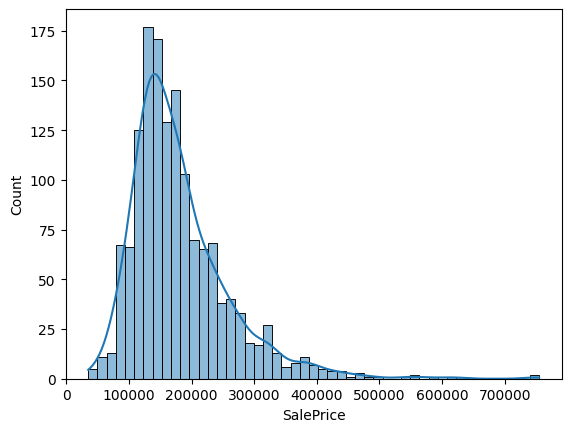

In [19]:
sns.histplot(num_cols["SalePrice"],kde=True)
plt.show()

In [20]:
num_cols["SalePrice"].skew()

np.float64(1.8828757597682129)

In [21]:
# a=num_cols["MSSubClass"].value_counts().sort_index()
# plt.bar(a.index,a.values)
# plt.xlabel("MSSubClass")
# plt.ylabel("count")
# plt.show()

Text(0, 0.5, 'SalePrice')

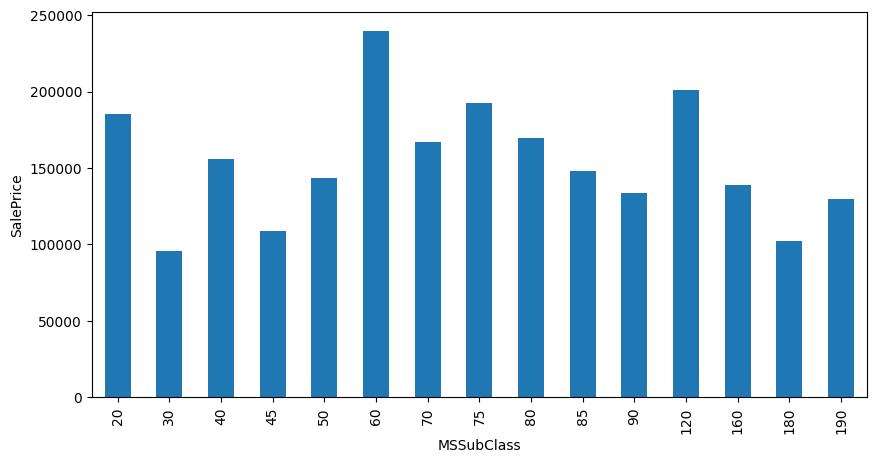

In [22]:
plt.figure(figsize=(10,5))
num_cols.groupby("MSSubClass")["SalePrice"].mean().plot(kind="bar")
plt.xlabel("MSSubClass")
plt.ylabel("SalePrice")

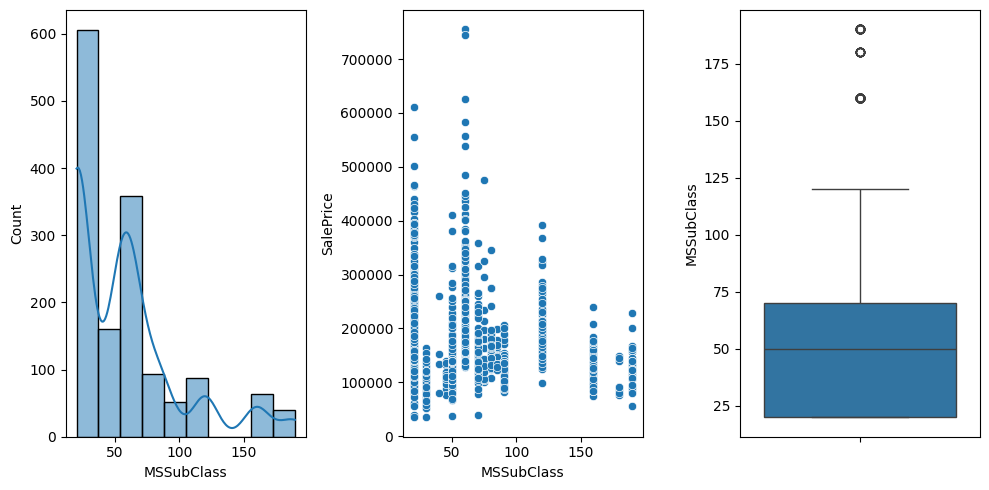

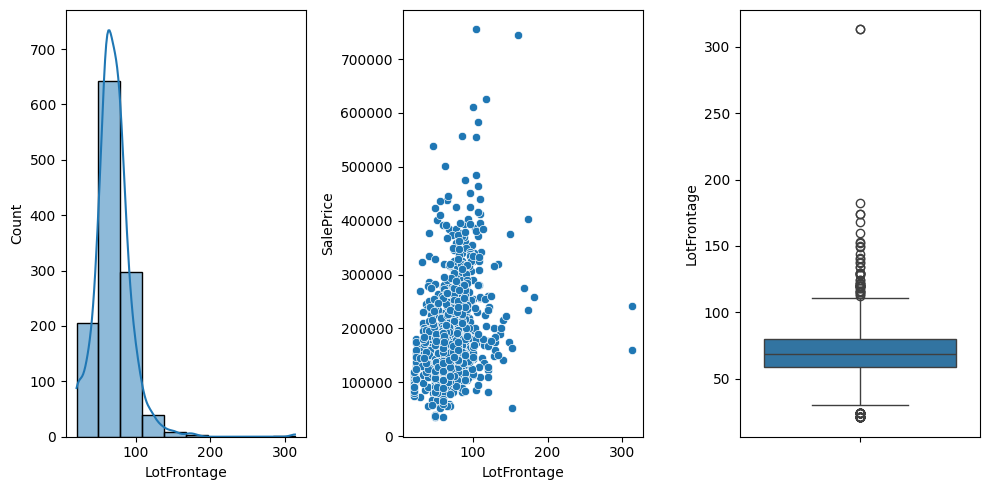

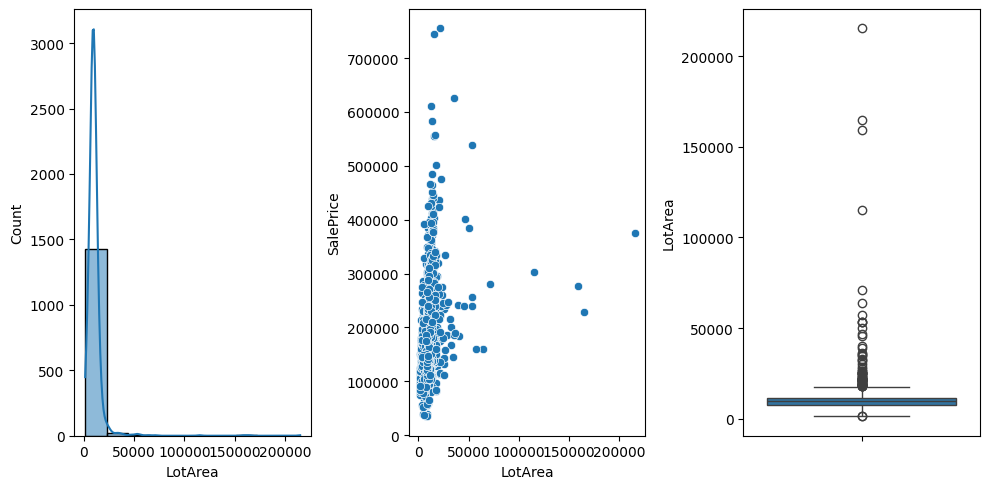

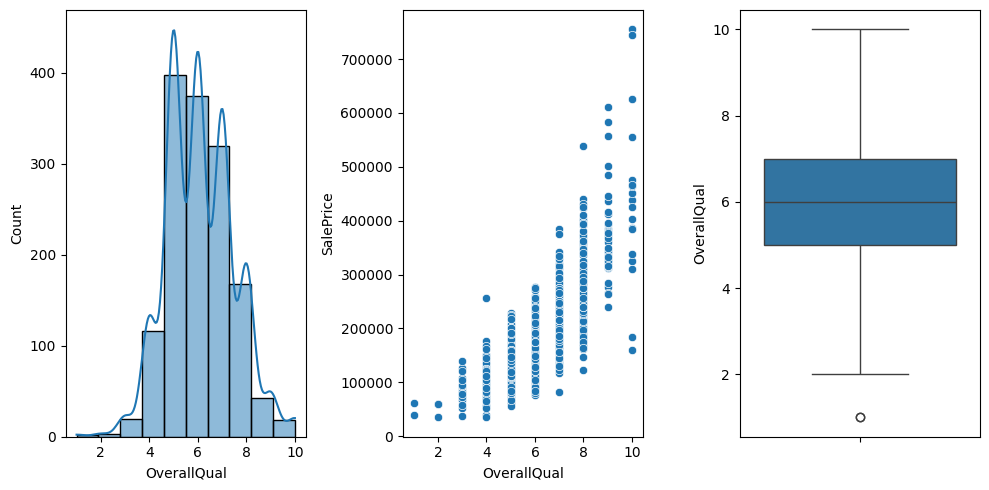

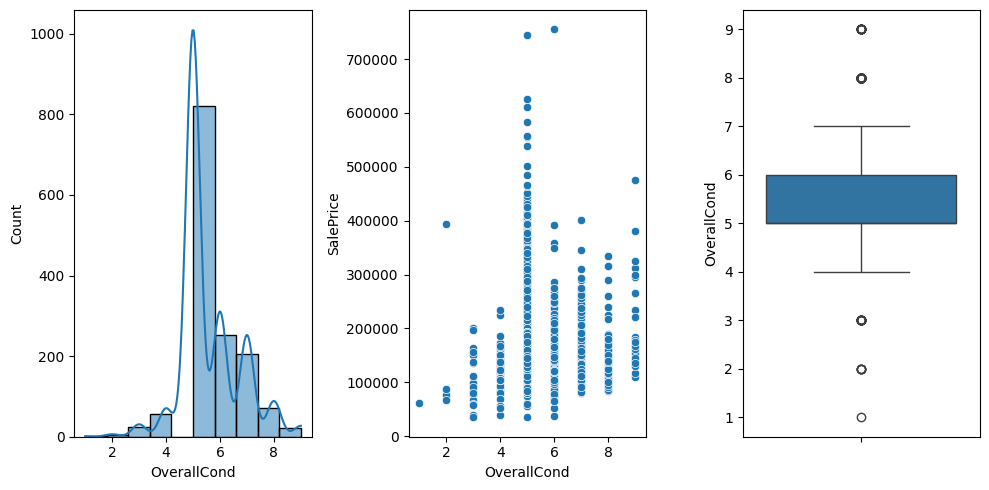

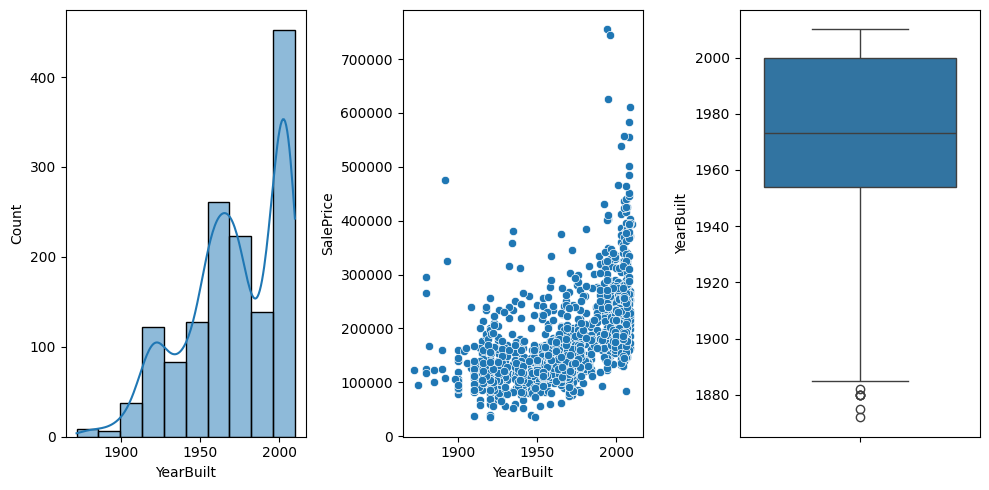

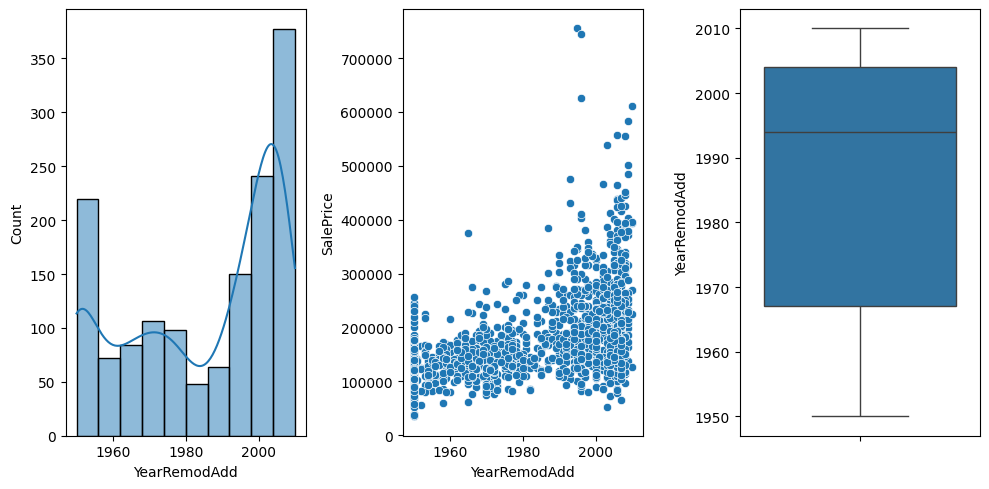

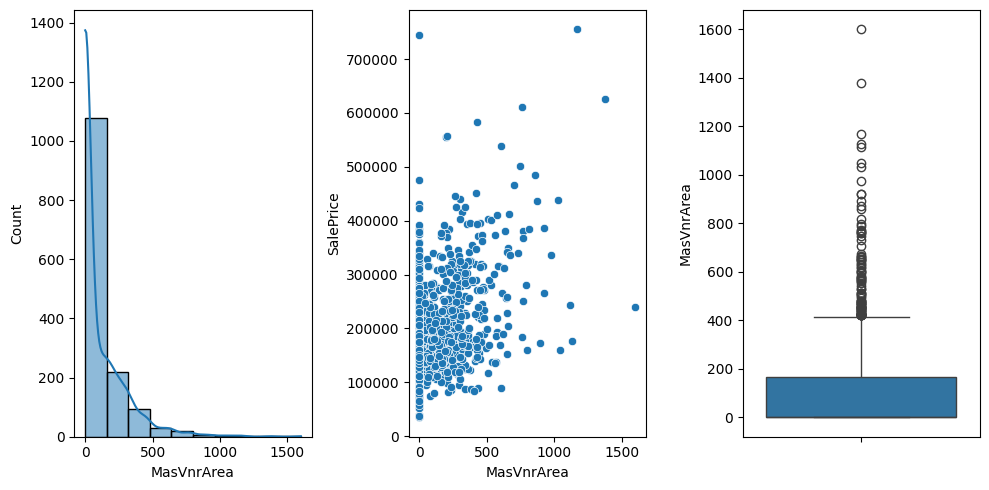

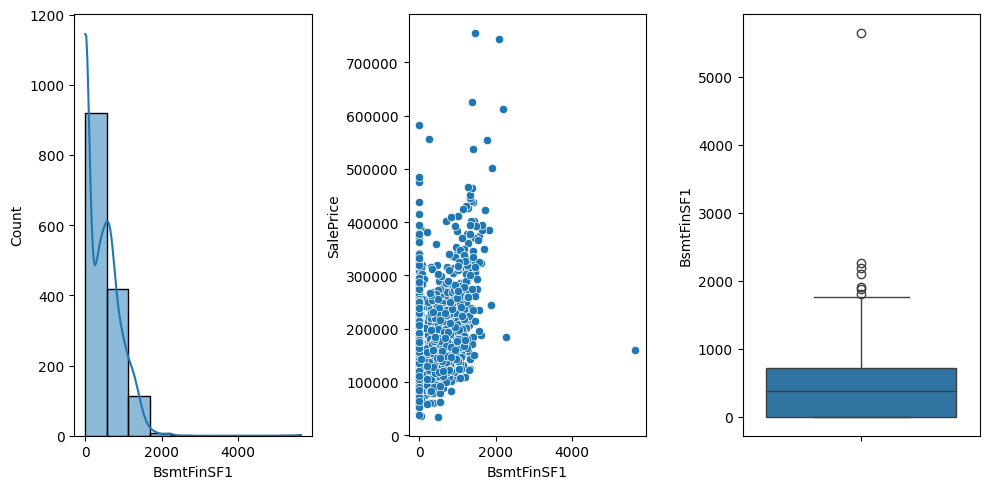

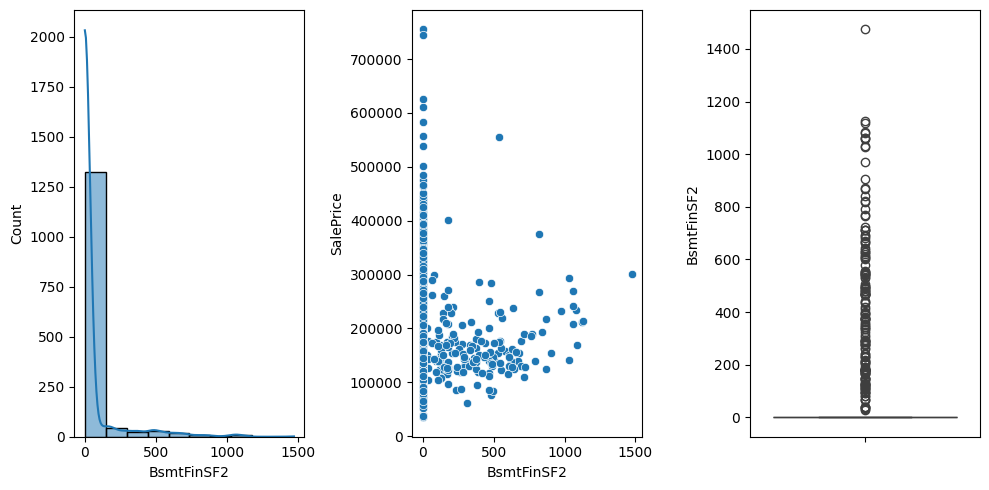

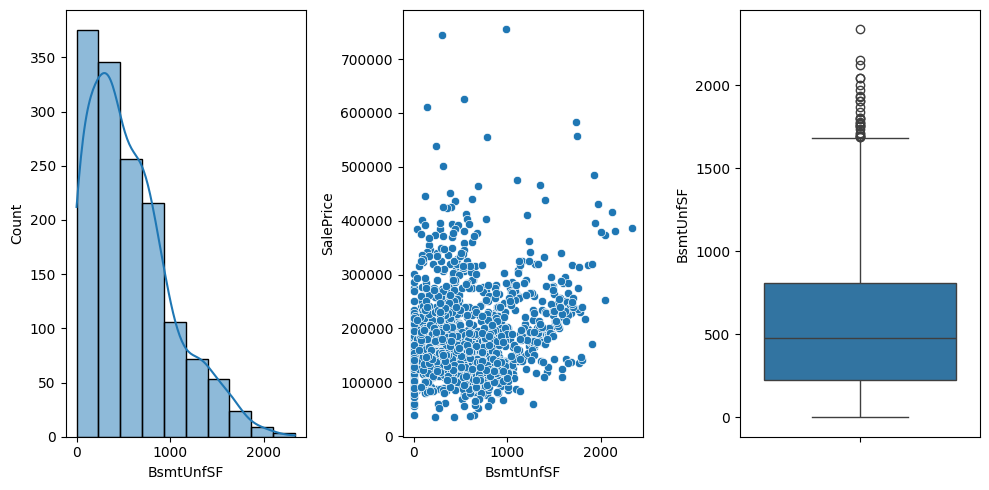

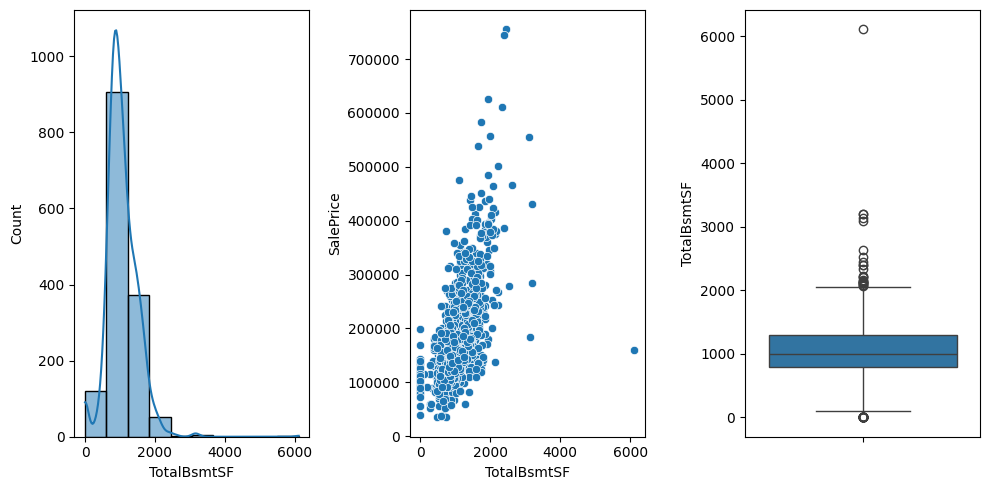

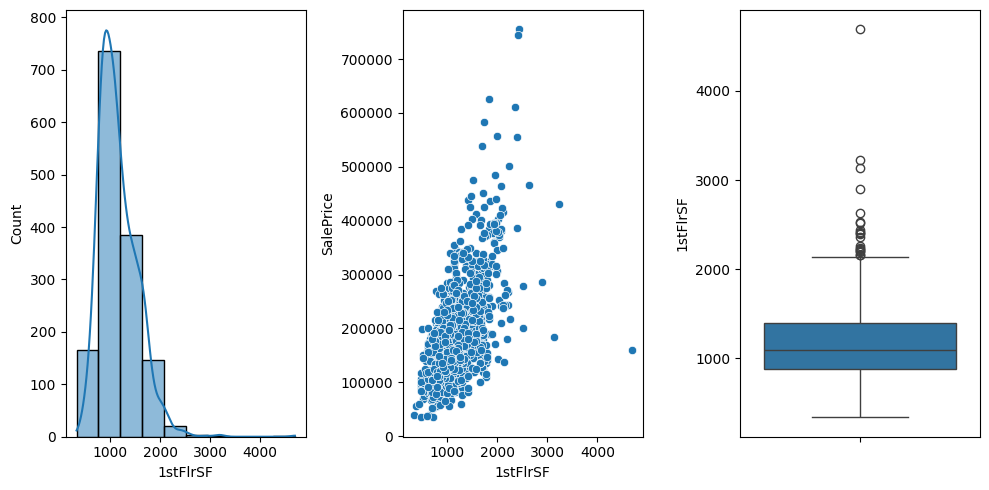

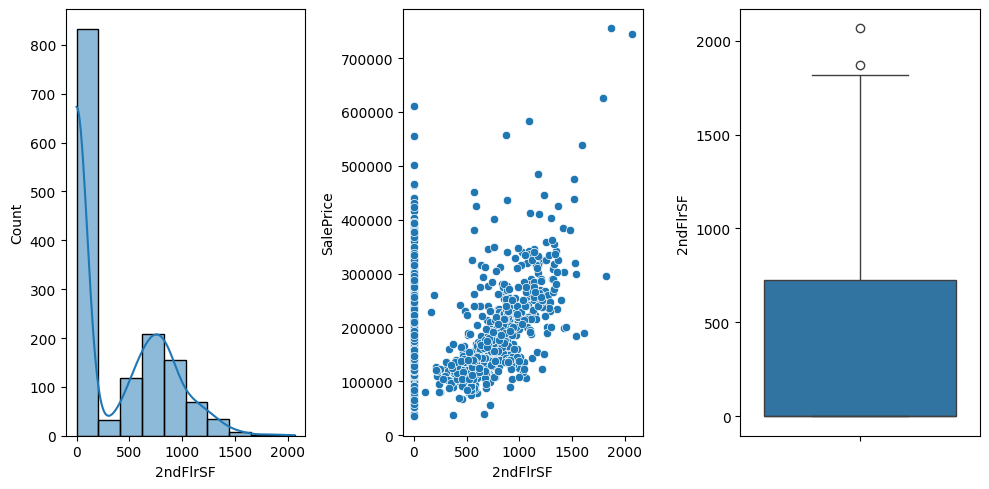

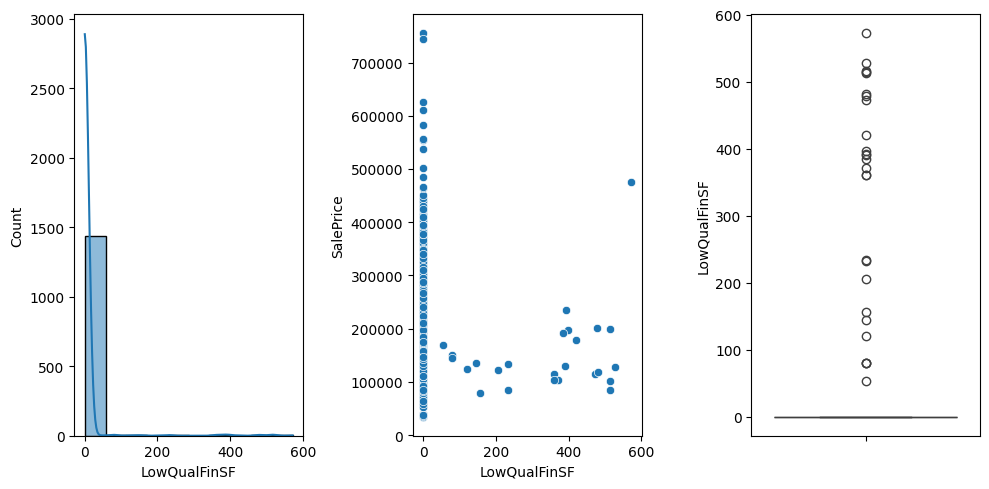

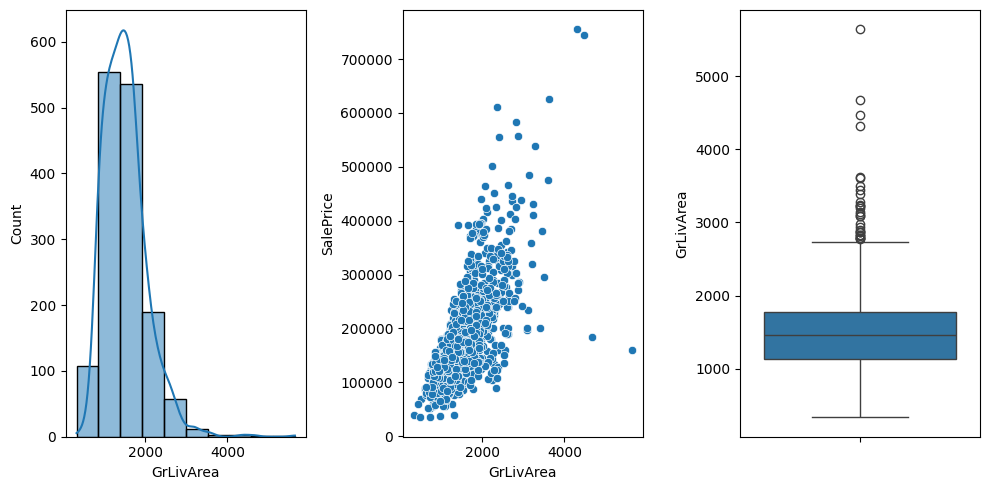

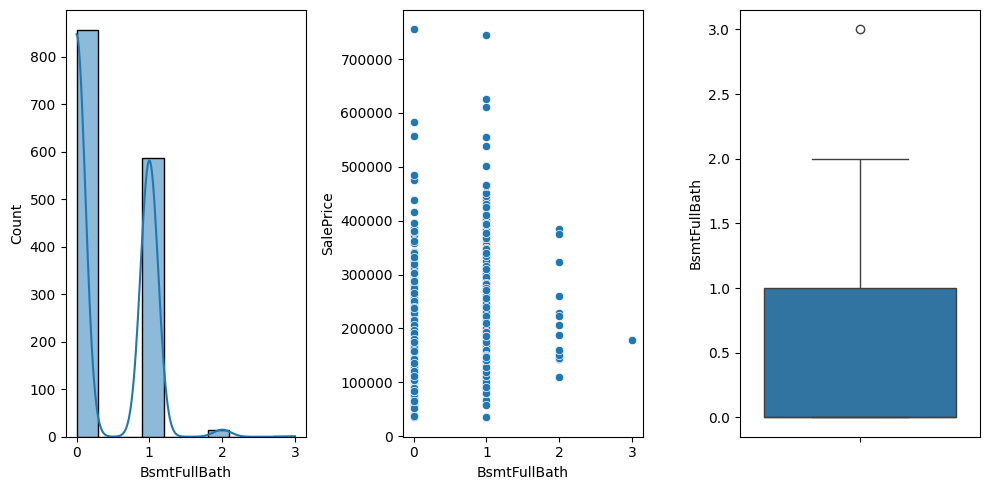

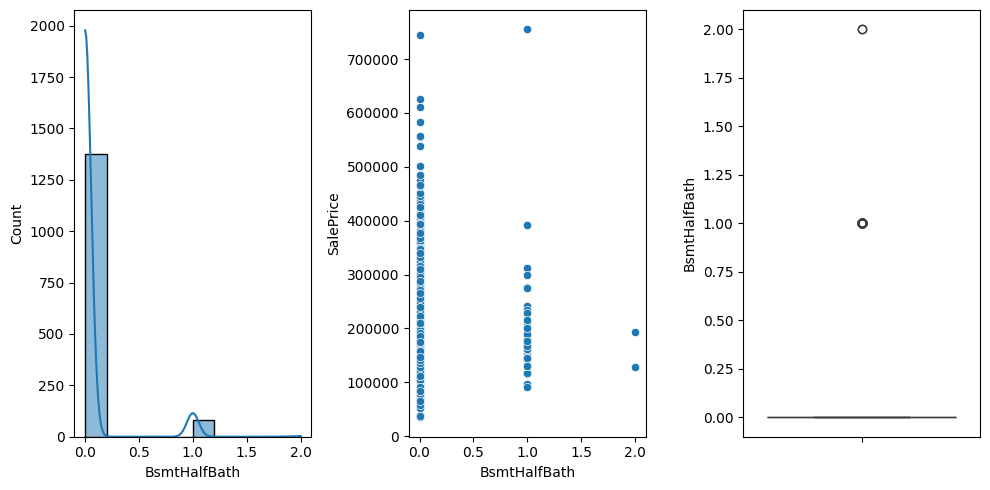

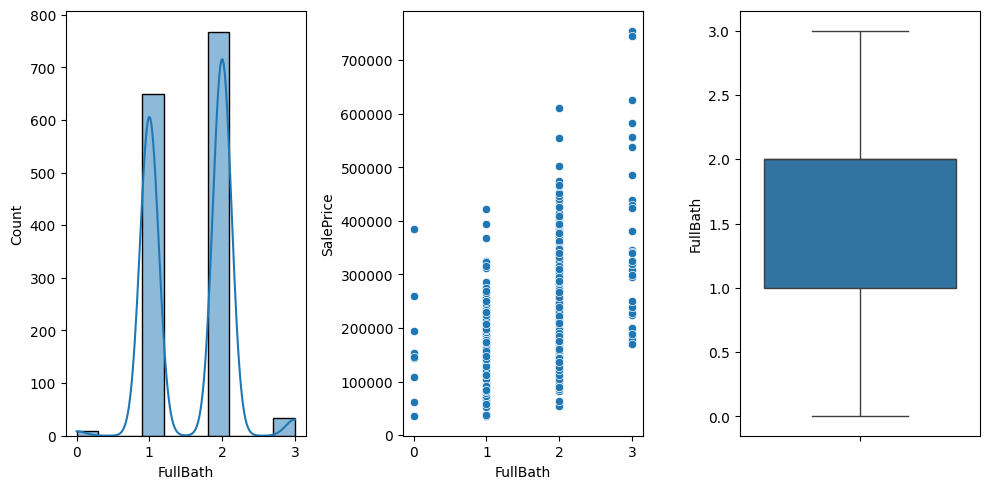

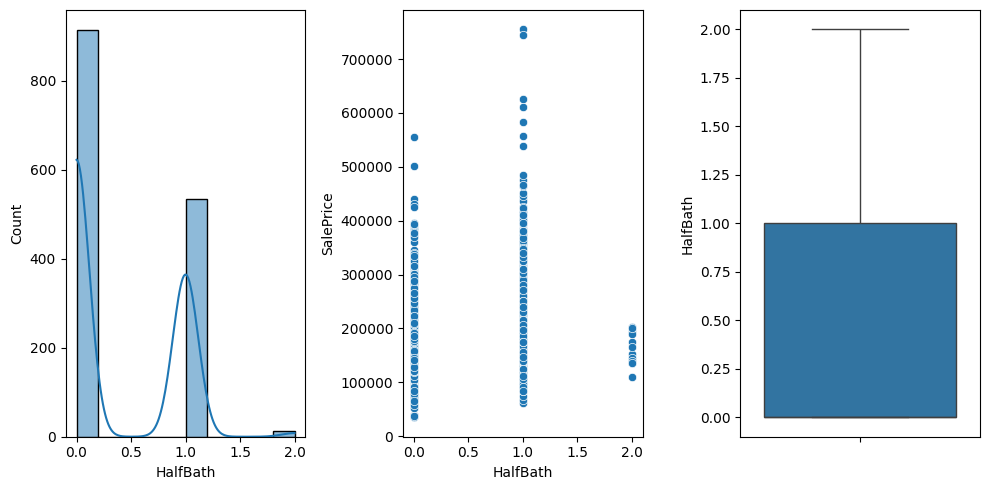

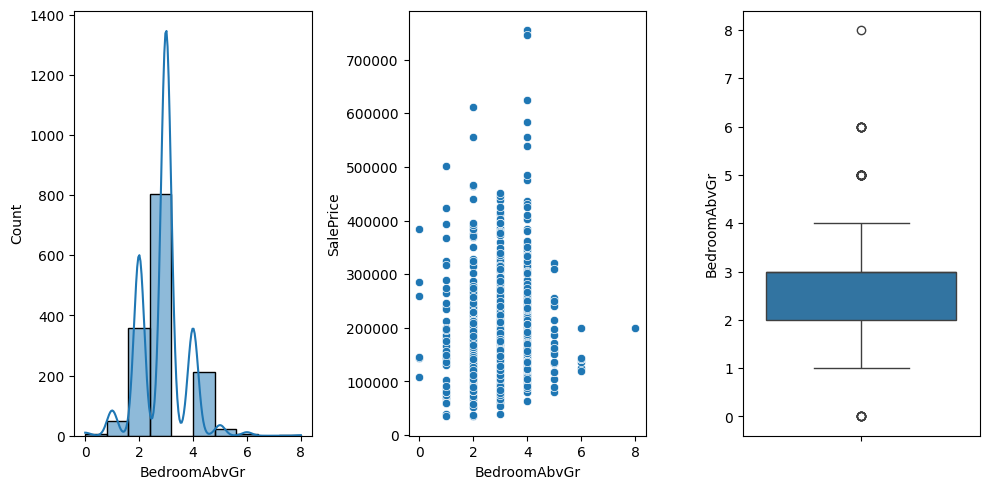

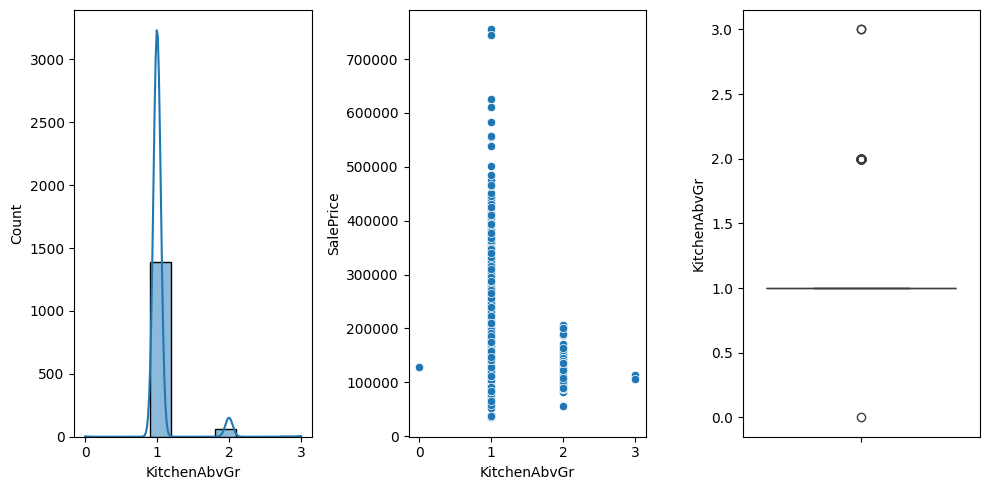

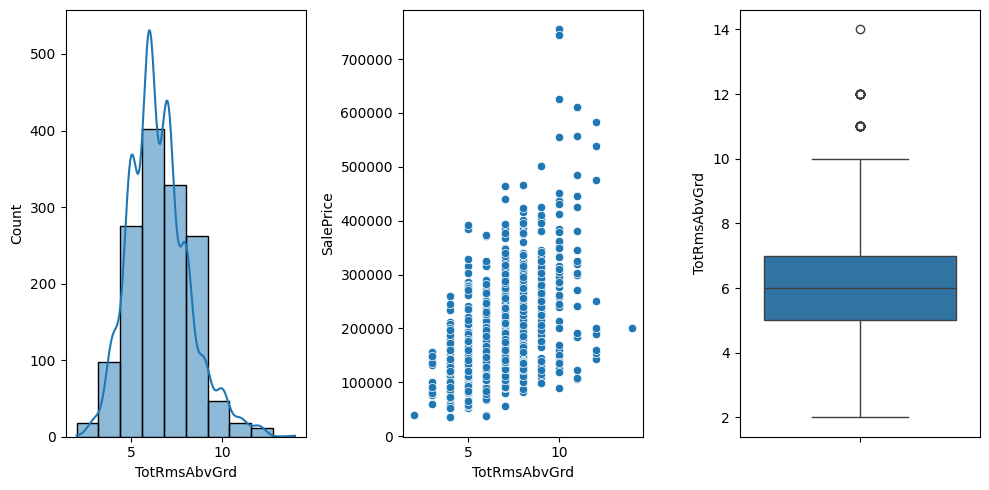

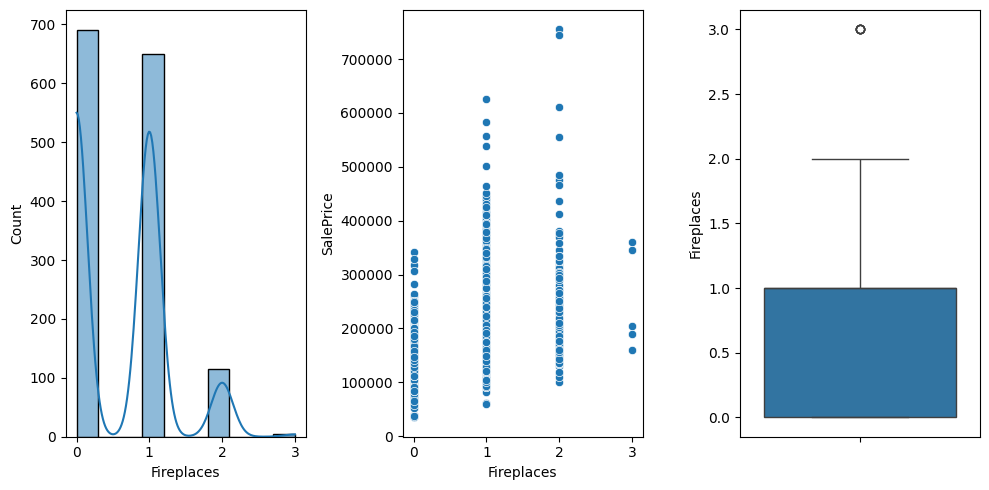

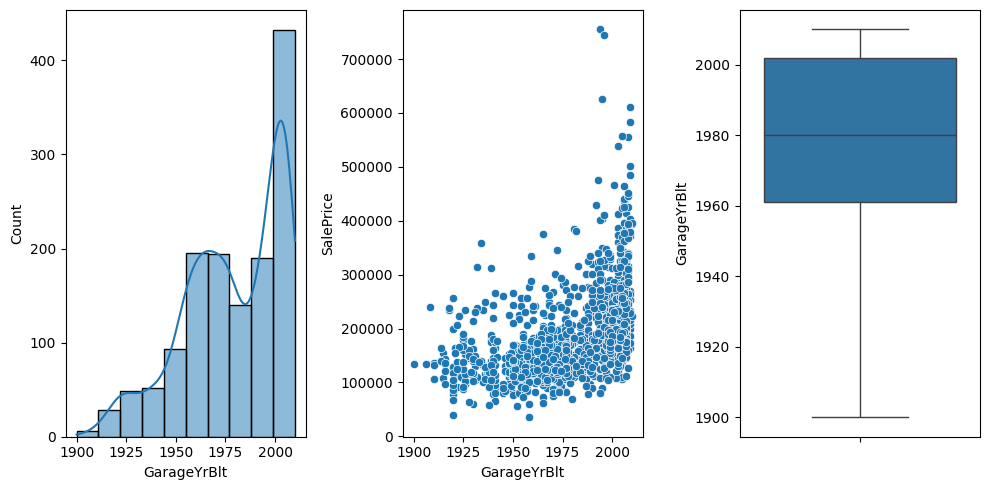

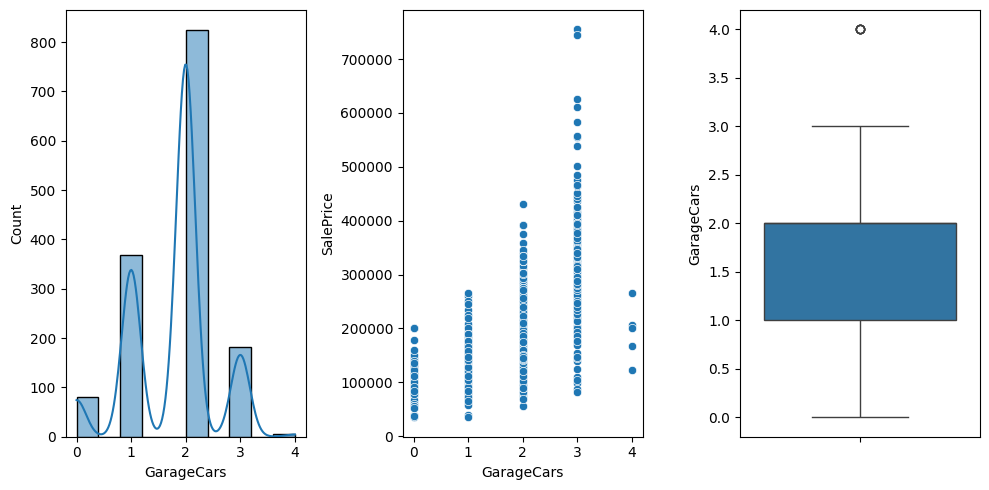

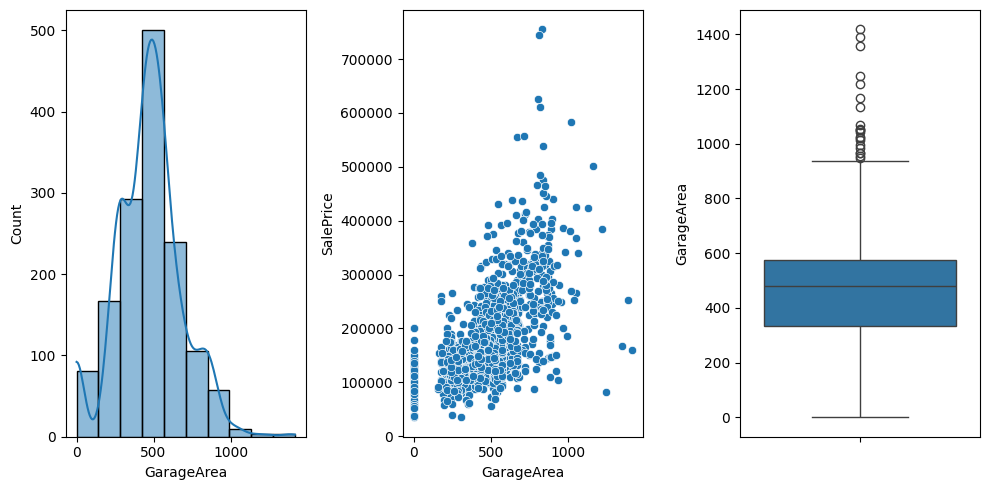

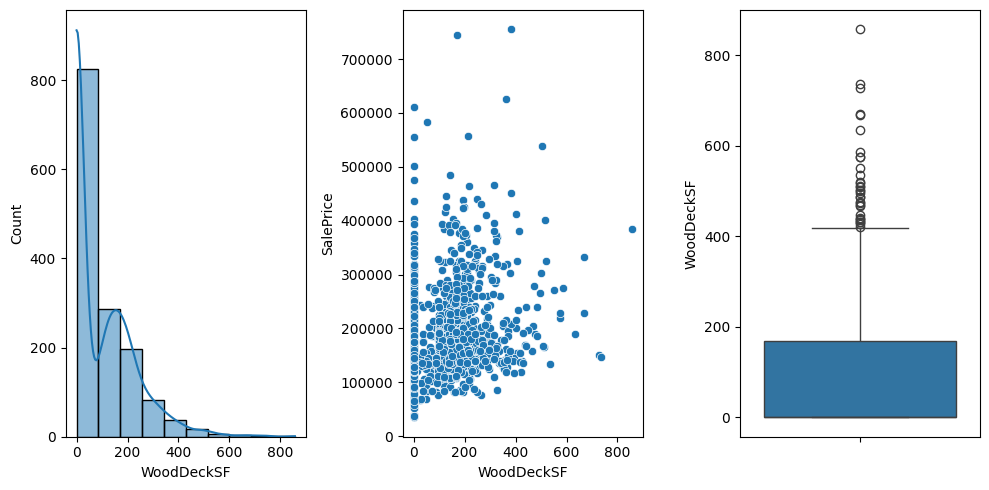

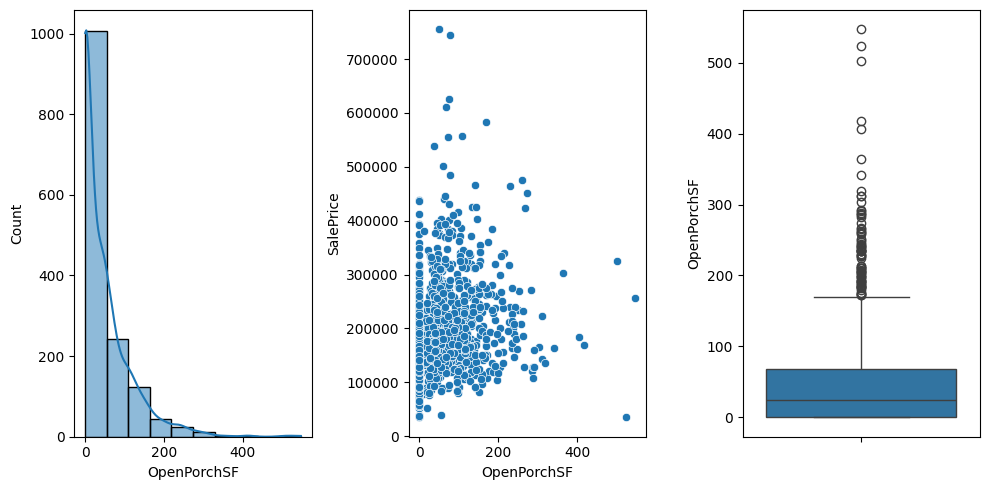

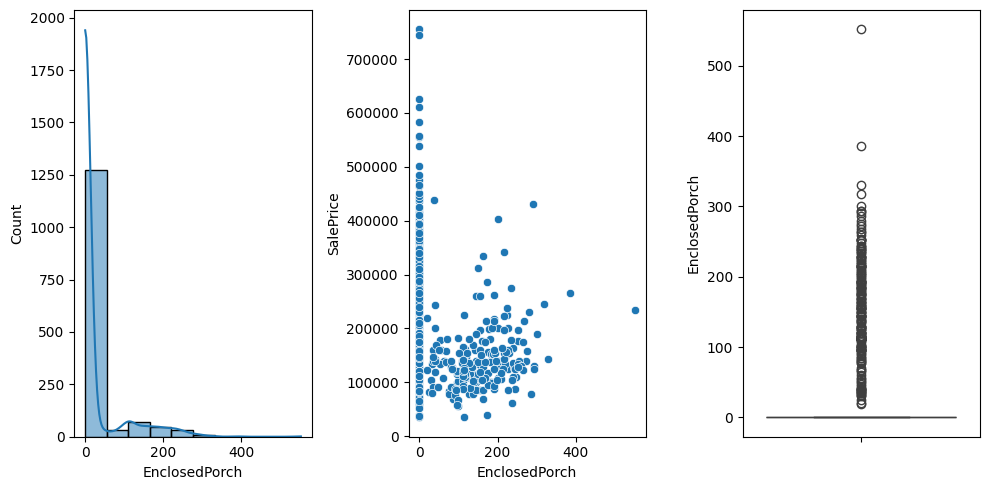

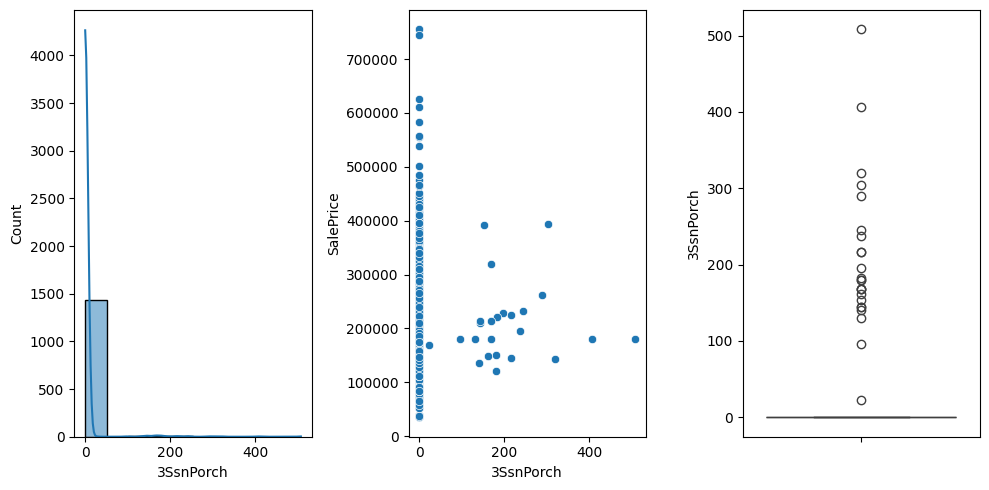

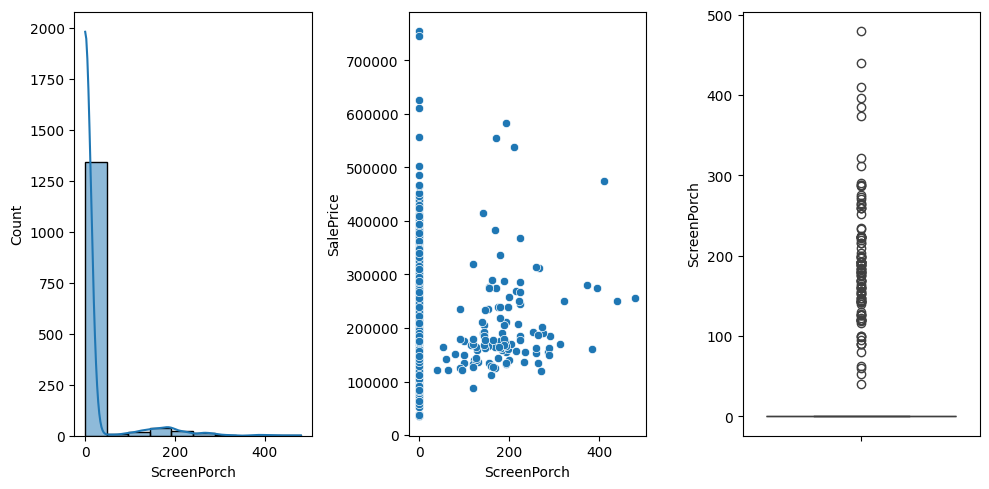

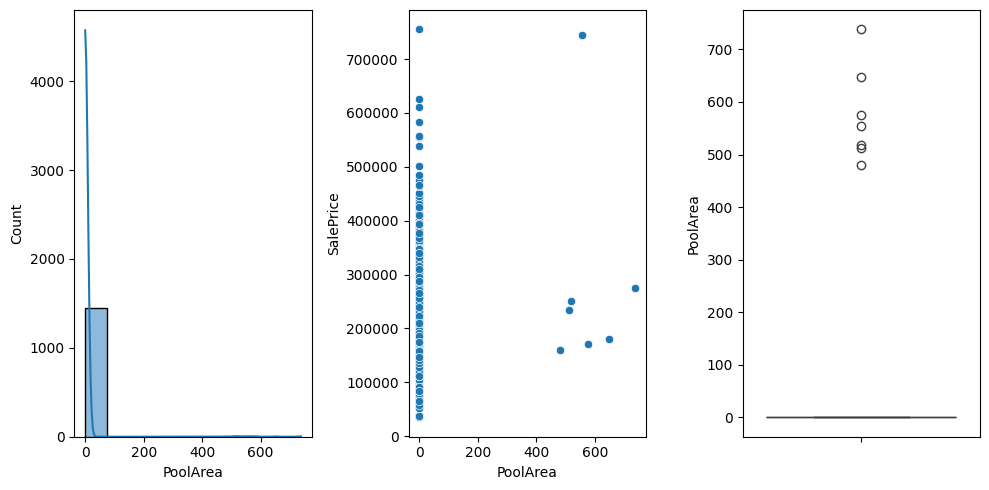

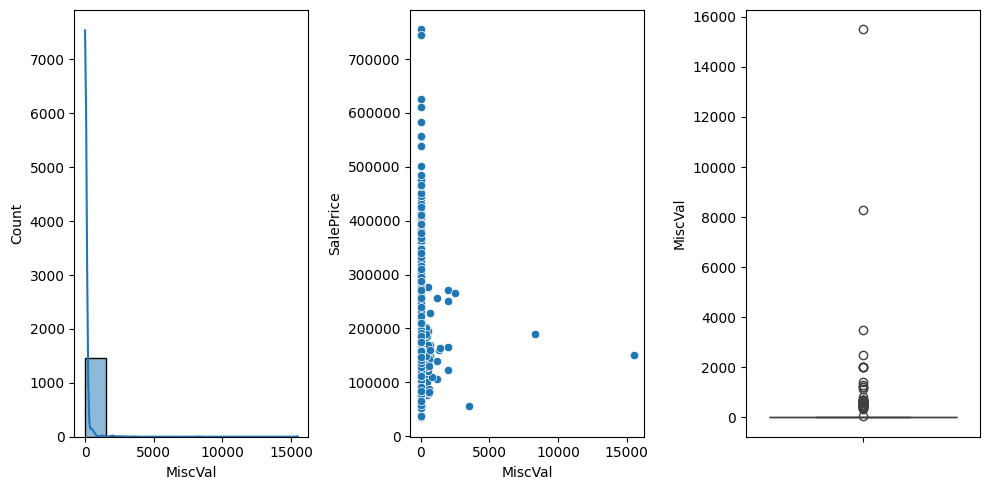

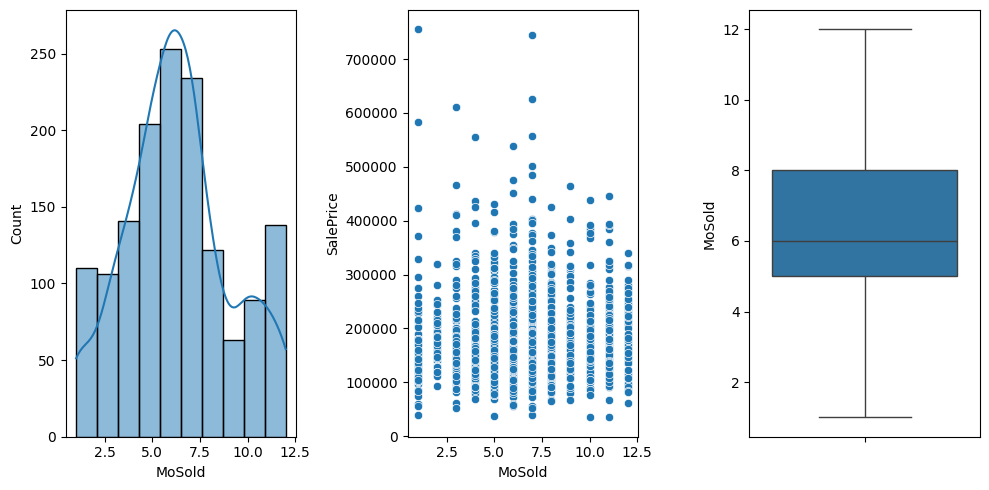

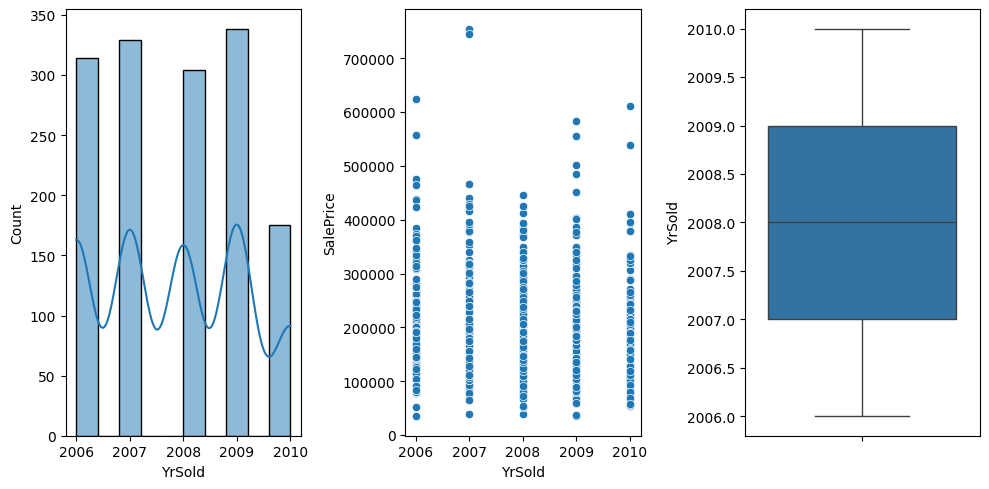

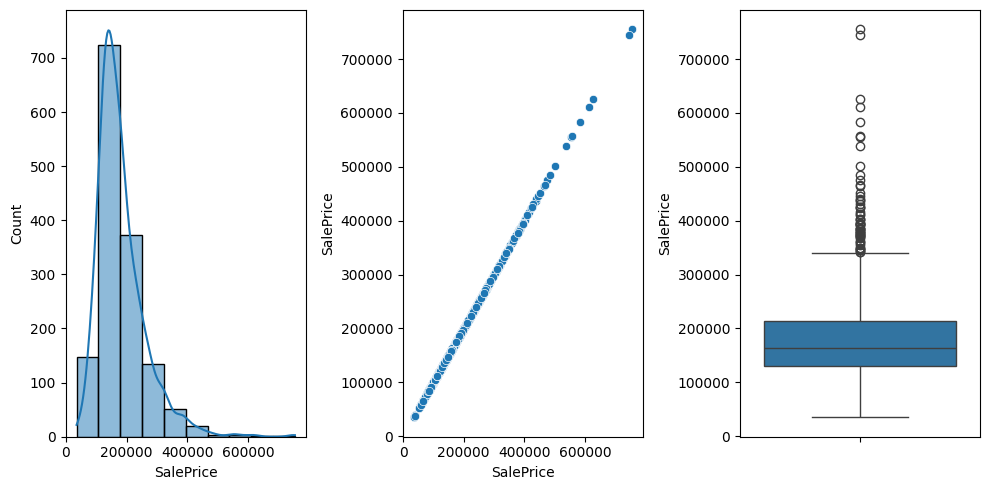

In [23]:
for col in num_cols.columns:
  plt.figure(figsize=(10,5))
  ax1=plt.subplot(1,3,1)
  ax2=plt.subplot(1,3,2)
  ax3=plt.subplot(1,3,3)
  sns.histplot(num_cols[col],kde=True,ax=ax1,bins=10)
  sns.scatterplot(x=num_cols[col],y=df["SalePrice"],ax=ax2)
  sns.boxplot(y=num_cols[col],ax=ax3)
  plt.tight_layout()
  plt.show()

In [24]:
num_cols.corr(numeric_only=True)["SalePrice"].sort_values(  ascending=False).head(10)
#

,SalePrice
SalePrice,1.000000
OverallQual,0.790982
GrLivArea,0.708624
GarageCars,0.640409
GarageArea,0.623431
TotalBsmtSF,0.613581
1stFlrSF,0.605852
FullBath,0.560664
TotRmsAbvGrd,0.533723
YearBuilt,0.522897


In [25]:
slected_col=df[["OverallQual",	"GrLivArea",	"GarageCars","TotalBsmtSF",	"1stFlrSF","FullBath",	"TotRmsAbvGrd",	"YearBuilt",
                ]]

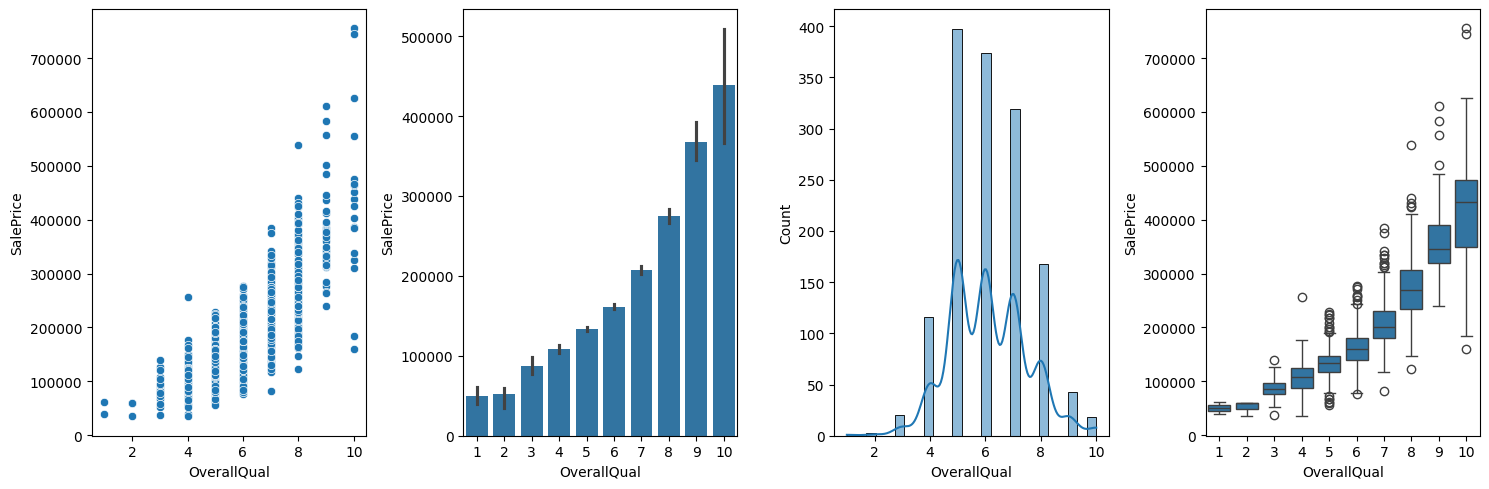

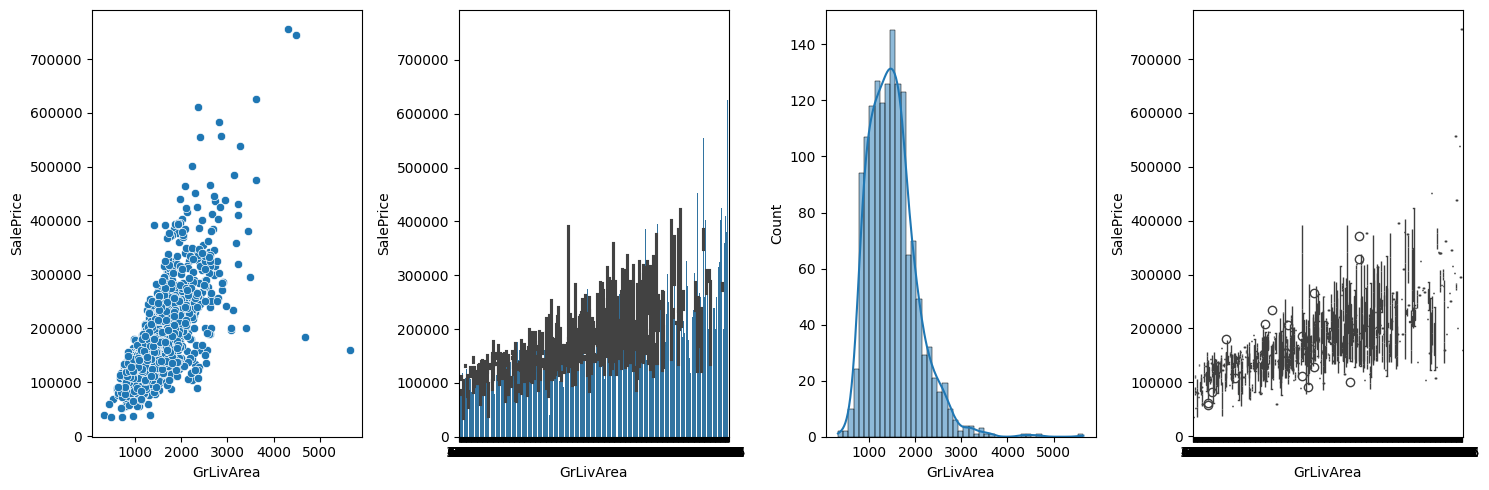

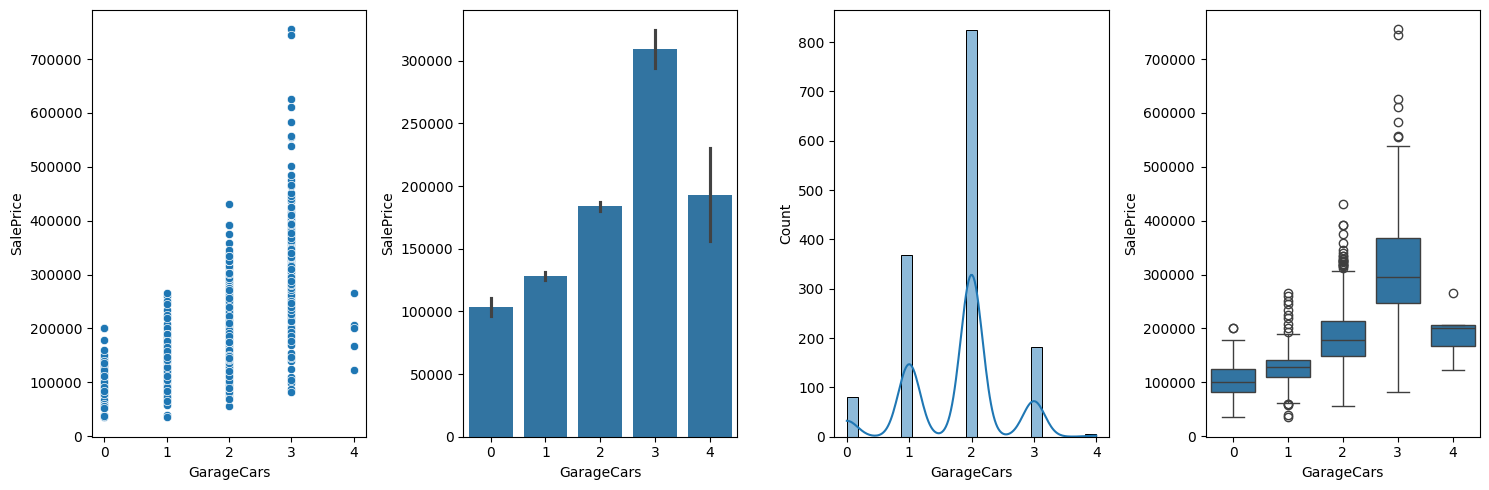

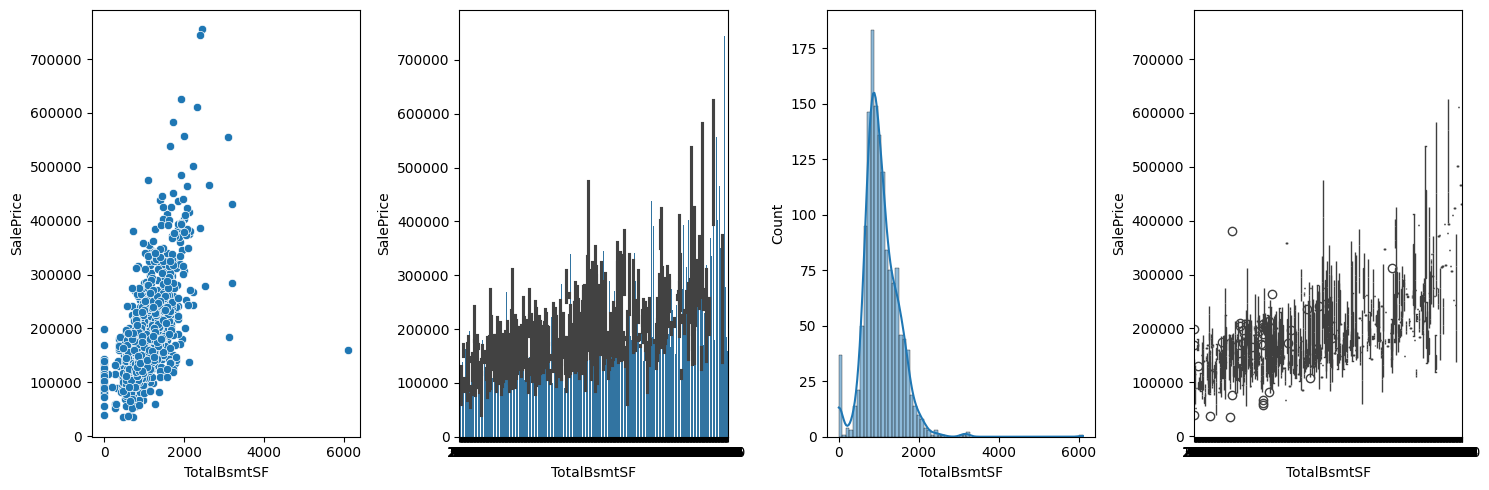

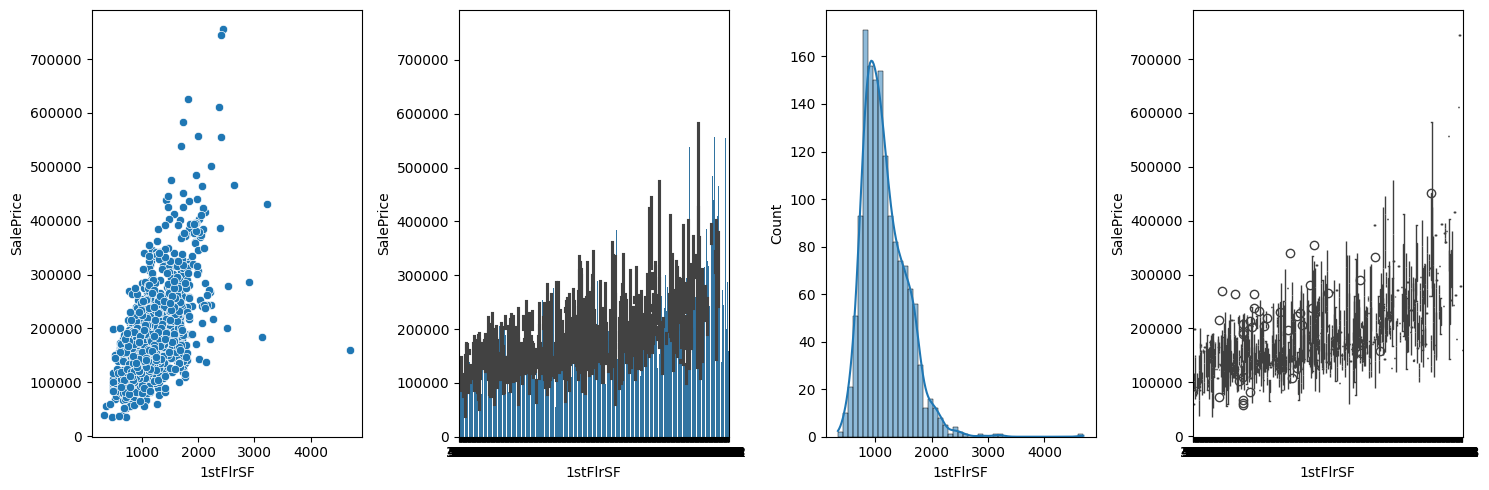

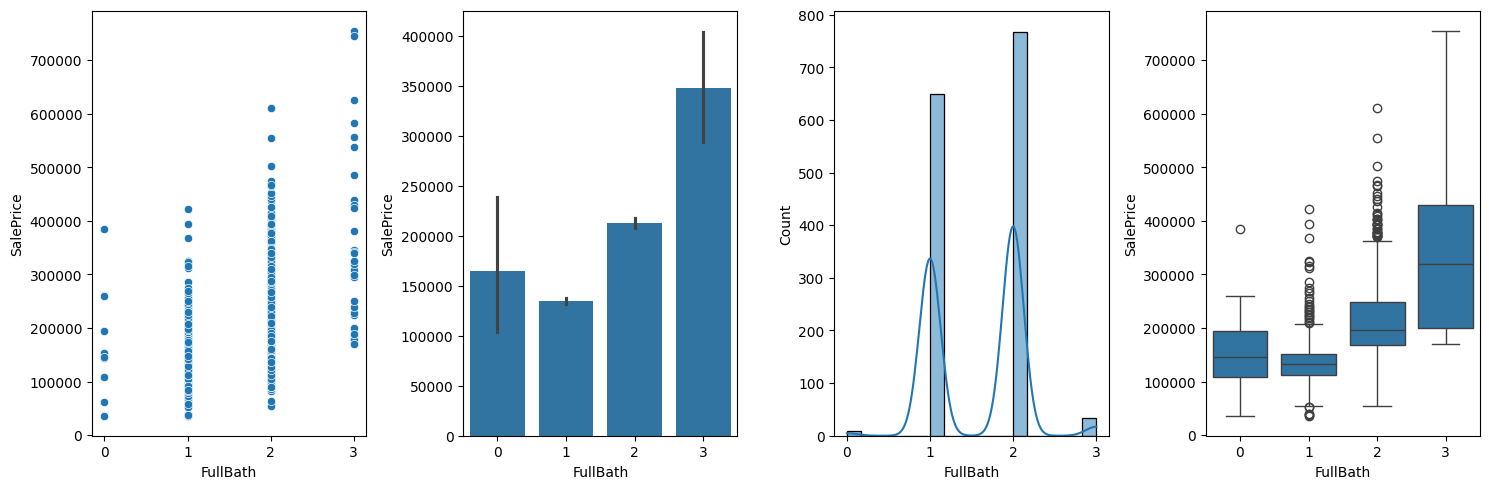

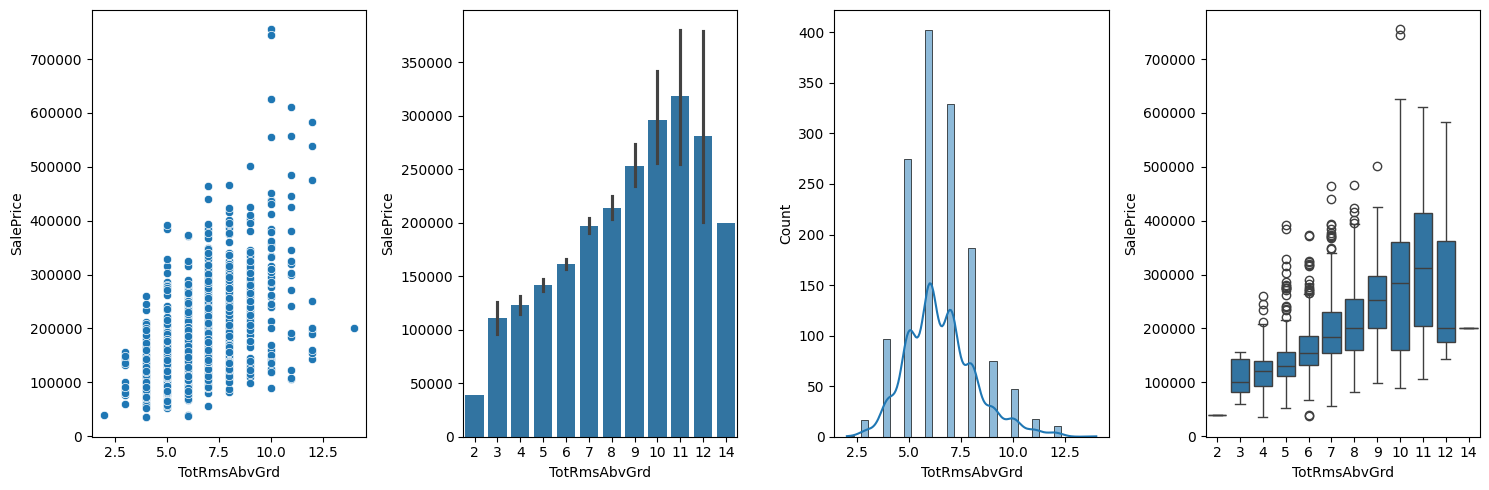

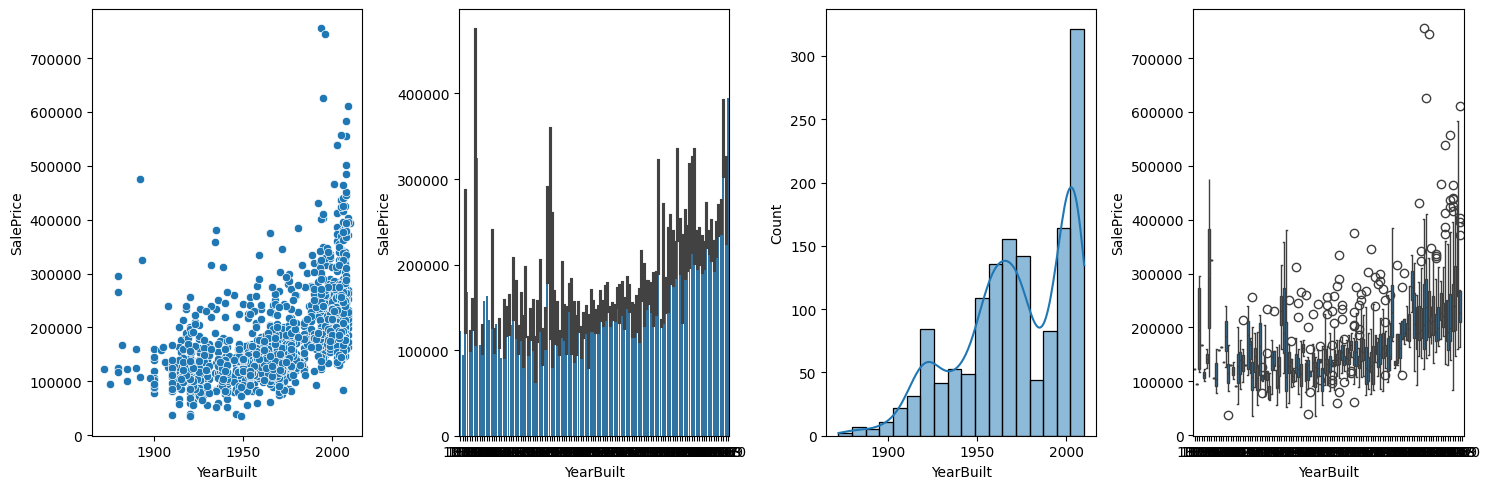

In [26]:
for col in slected_col.columns:
  plt.figure(figsize=(15,5))
  ax1=plt.subplot(1,4,1)
  ax2=plt.subplot(1,4,2)
  ax3=plt.subplot(1,4,3)
  ax4=plt.subplot(1,4,4)
  sns.scatterplot(x=slected_col[col],y=df["SalePrice"],ax=ax1)
  sns.barplot(x=slected_col[col],y=df["SalePrice"],ax=ax2)
  sns.boxplot(x=slected_col[col],y=df["SalePrice"],ax=ax4)
  sns.histplot(x=slected_col[col],kde=True,ax=ax3)
  plt.tight_layout()
  plt.show()

In [27]:
slected_col.skew().sort_values(ascending=False)

,0
TotalBsmtSF,1.524255
1stFlrSF,1.376757
GrLivArea,1.366560
TotRmsAbvGrd,0.676341
OverallQual,0.216944
FullBath,0.036562
GarageCars,-0.342549
YearBuilt,-0.613461


In [28]:
slected_col.isnull().mean()*100

,0
OverallQual,0.0
GrLivArea,0.0
GarageCars,0.0
TotalBsmtSF,0.0
1stFlrSF,0.0
FullBath,0.0
TotRmsAbvGrd,0.0
YearBuilt,0.0


In [29]:
from sklearn.preprocessing import PowerTransformer

pt = PowerTransformer(method='yeo-johnson')


    # slected_col[col+"transformed"]=log_transformer.fit_transform(slected_col[[col]])


# df["SalePrice_log"] = log_transformer.fit_transform(df[["SalePrice"]])

In [30]:
for col in slected_col.columns:
   slected_col[col+"transformed"]=pt.fit_transform(slected_col[[col]])



/tmp/ipykernel_4150/1630802990.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  slected_col[col+"transformed"]=pt.fit_transform(slected_col[[col]])
/tmp/ipykernel_4150/1630802990.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  slected_col[col+"transformed"]=pt.fit_transform(slected_col[[col]])
/tmp/ipykernel_4150/1630802990.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the d

In [31]:
slected_col.columns

Index(['OverallQual', 'GrLivArea', 'GarageCars', 'TotalBsmtSF', '1stFlrSF',
       'FullBath', 'TotRmsAbvGrd', 'YearBuilt', 'OverallQualtransformed',
       'GrLivAreatransformed', 'GarageCarstransformed',
       'TotalBsmtSFtransformed', '1stFlrSFtransformed', 'FullBathtransformed',
       'TotRmsAbvGrdtransformed', 'YearBuilttransformed'],
      dtype='object')

In [32]:
original_cols = [
    "OverallQual",
    "GrLivArea",
    "GarageCars",
    "TotalBsmtSF",
    "1stFlrSF",
    "FullBath",
    "TotRmsAbvGrd",
    "YearBuilt"
]

transformed_cols = [
    "OverallQualtransformed",
    "GrLivAreatransformed",
    "GarageCarstransformed",
    "TotalBsmtSFtransformed",
    "1stFlrSFtransformed",
    "FullBathtransformed",
    "TotRmsAbvGrdtransformed",
    "YearBuilttransformed"
]

comparison = pd.DataFrame({
    "Original Skew": slected_col[original_cols].skew().values,
    "Yeo-Johnson Skew": slected_col[transformed_cols].skew().values
}, index=original_cols)

comparison

,Original Skew,Yeo-Johnson Skew
OverallQual,0.216944,0.018233
GrLivArea,1.366560,0.000171
GarageCars,-0.342549,-0.024840
TotalBsmtSF,1.524255,0.232534
1stFlrSF,1.376757,-0.001106
FullBath,0.036562,-0.049435
TotRmsAbvGrd,0.676341,0.001879
YearBuilt,-0.613461,-0.134920


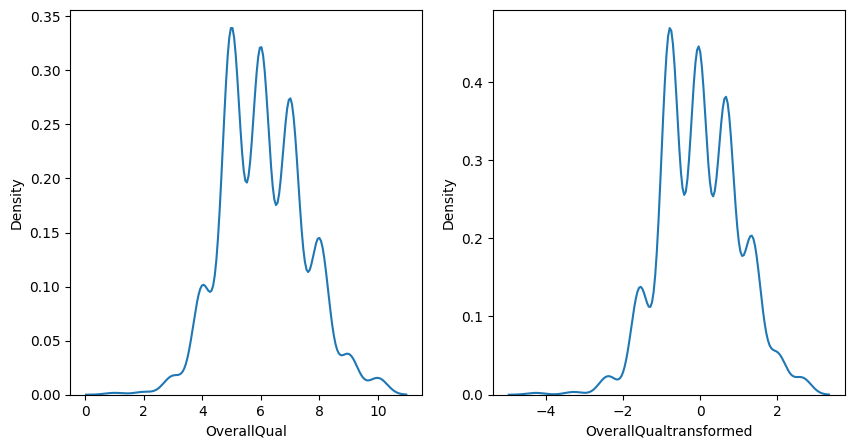

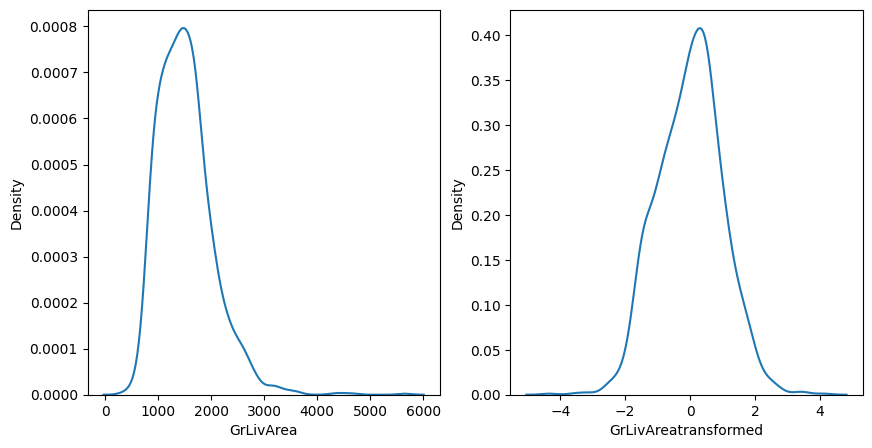

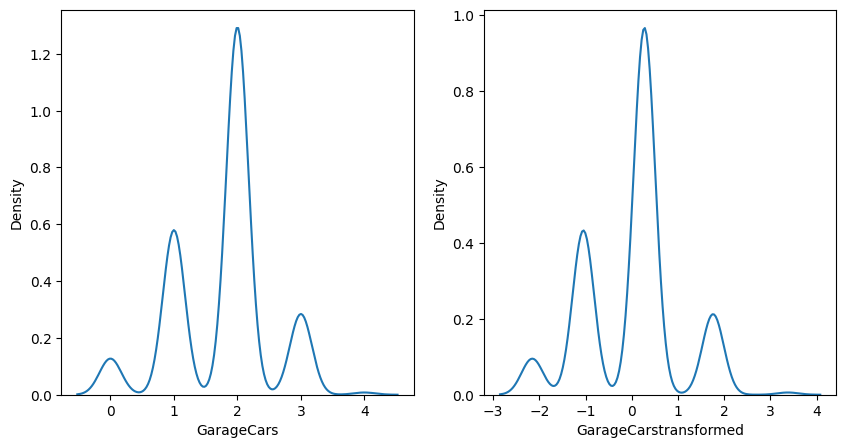

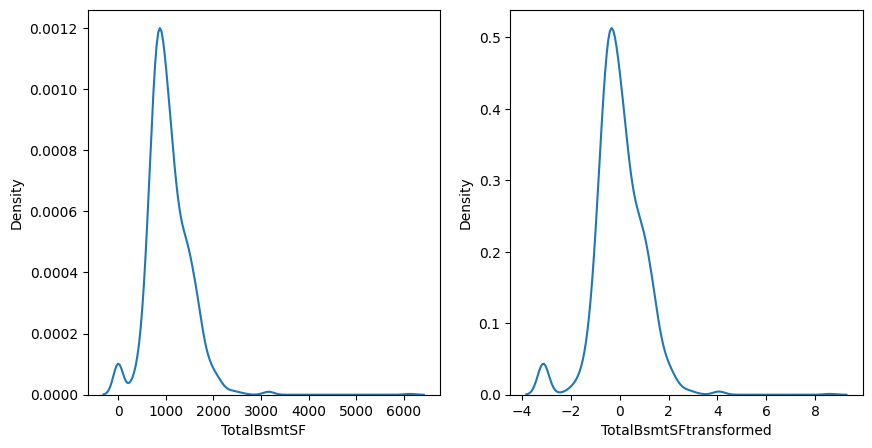

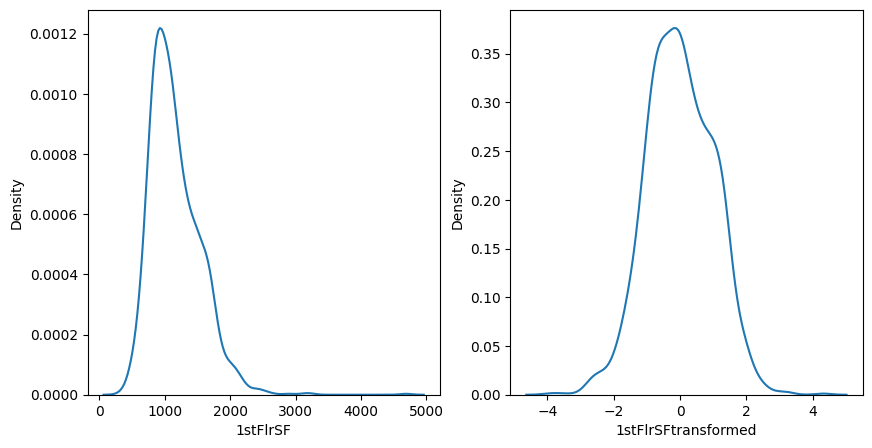

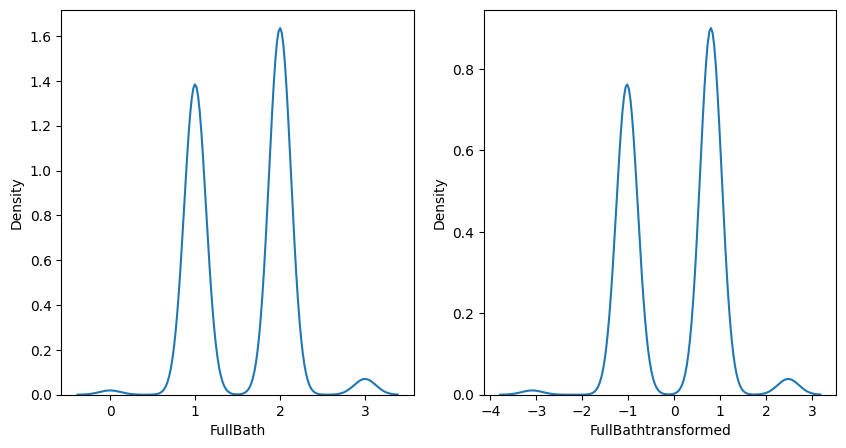

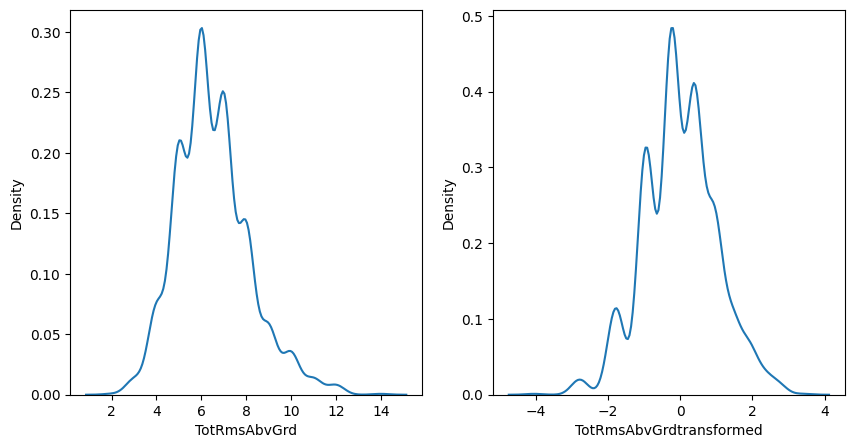

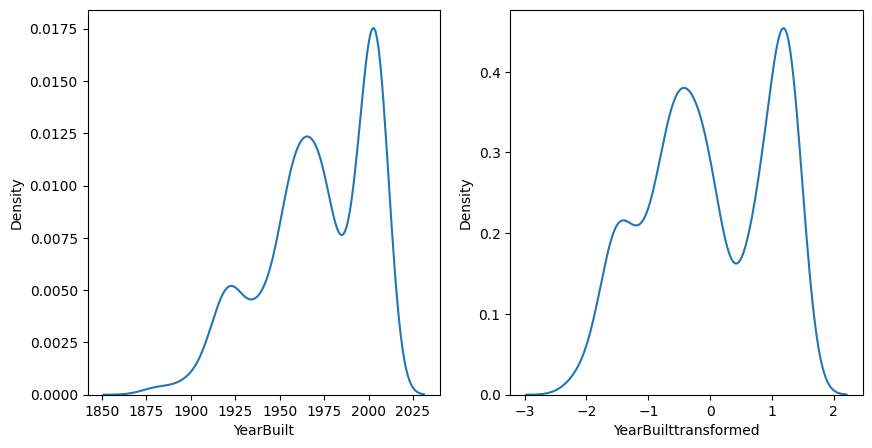

In [33]:
for col in original_cols:
  plt.figure(figsize=(10,5))
  ax1=plt.subplot(1,2,1)
  ax2=plt.subplot(1,2,2)
  sns.kdeplot(slected_col[col],ax=ax1)
  sns.kdeplot(slected_col[col+"transformed"],ax=ax2)
  plt.show()

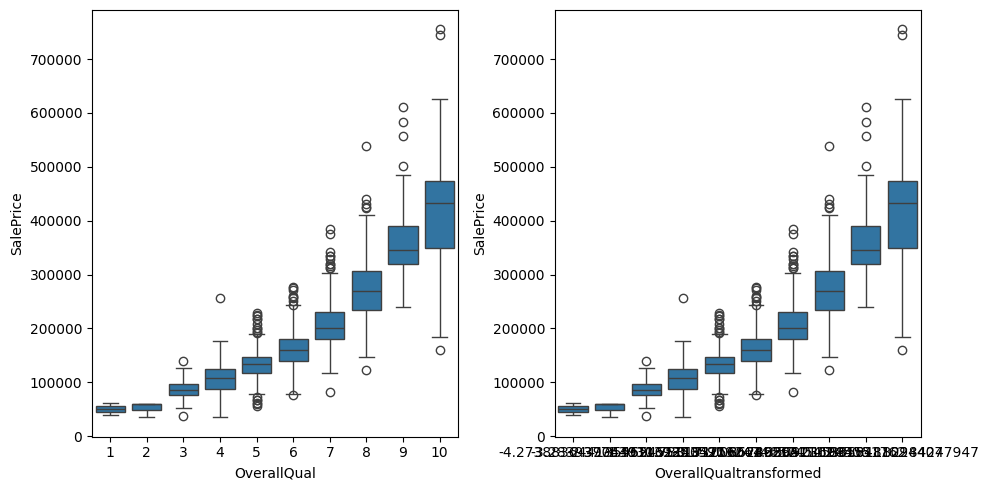

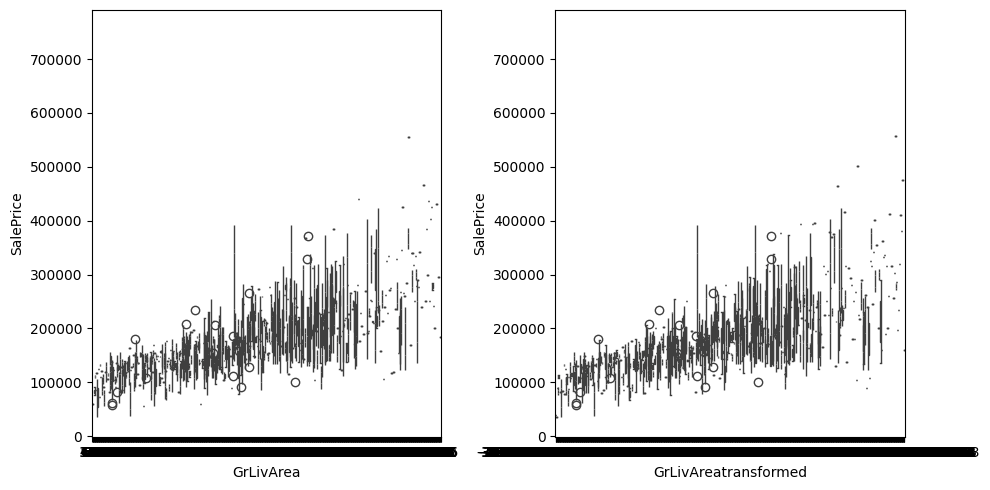

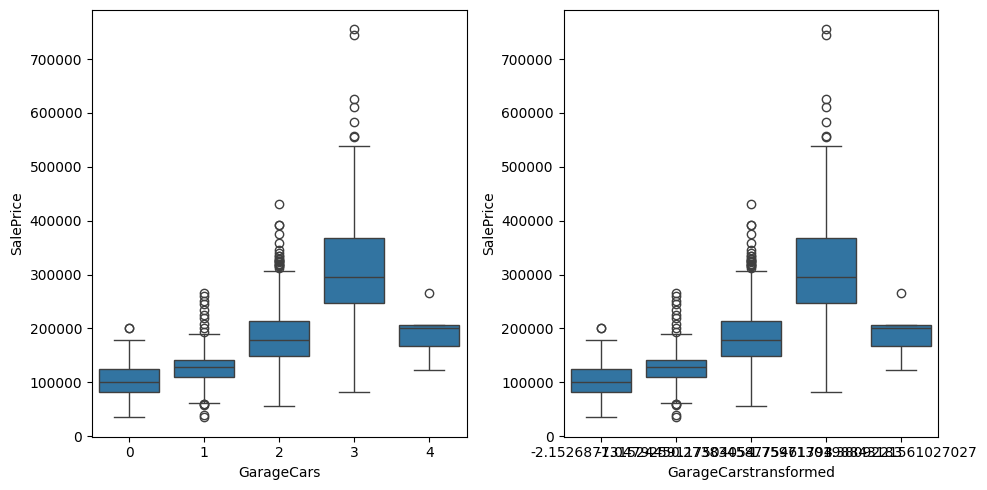

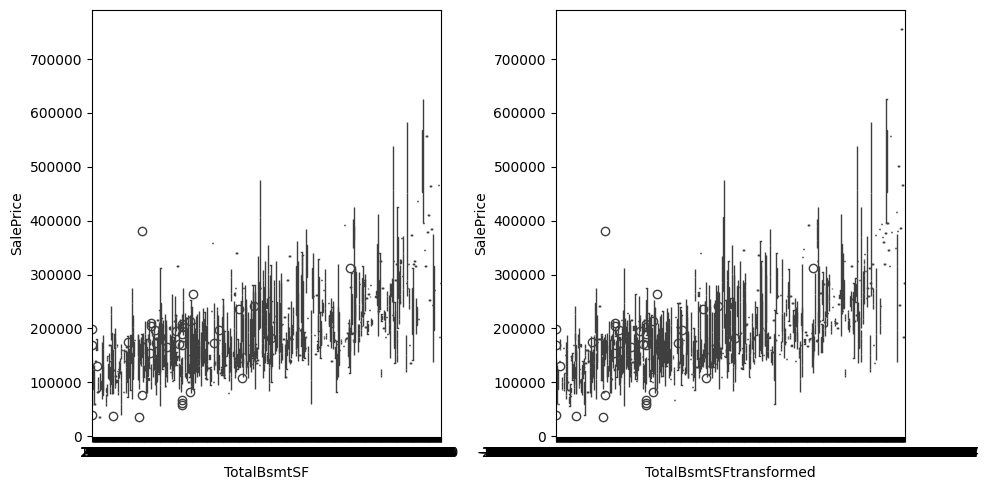

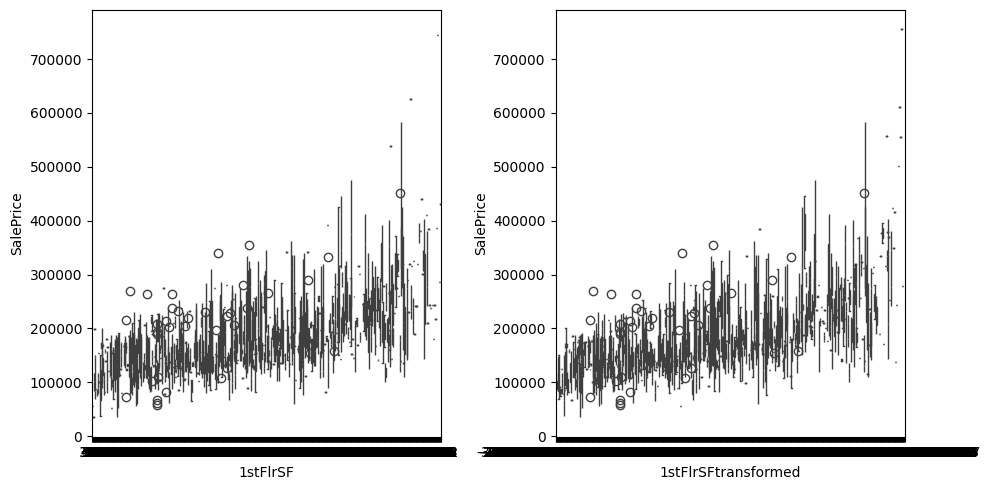

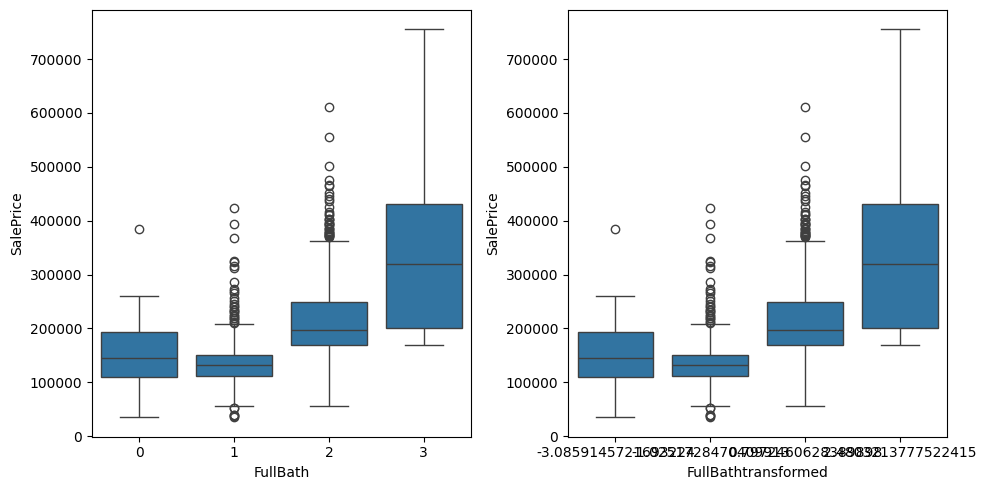

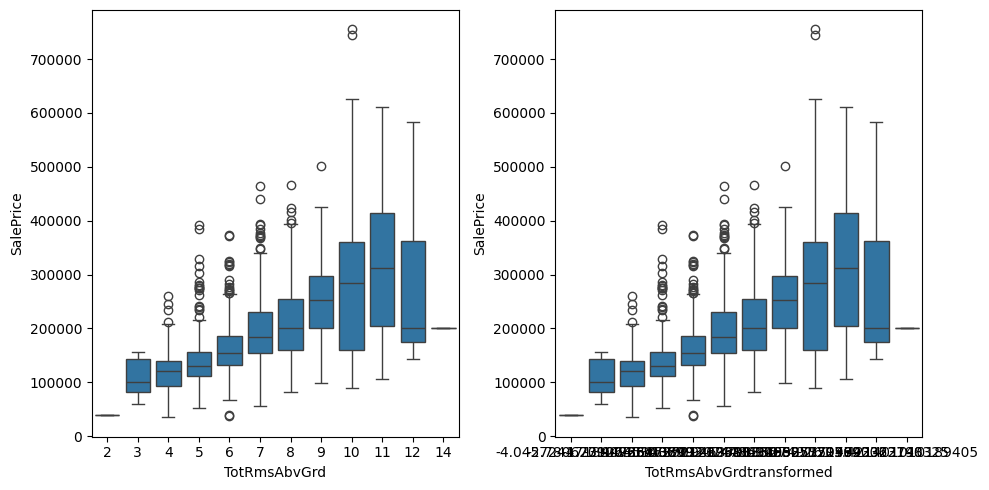

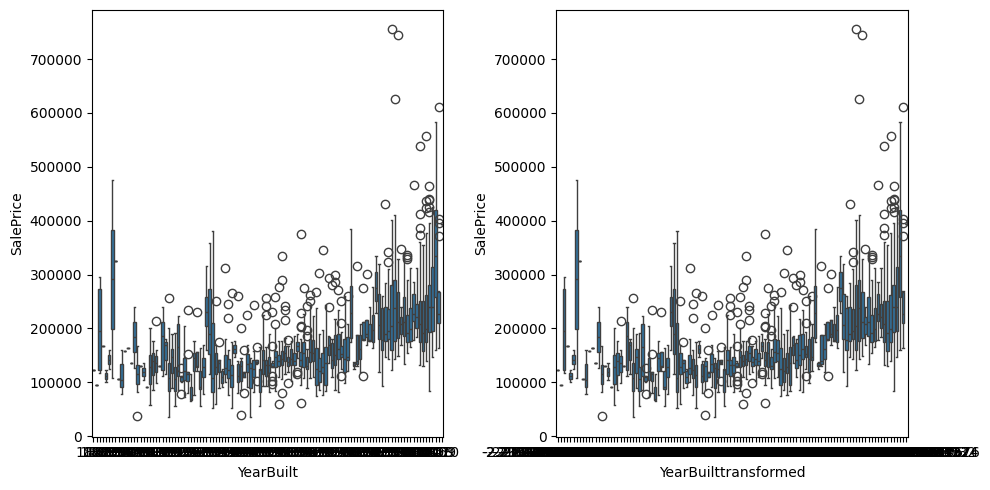

In [34]:
for col in original_cols:
  plt.figure(figsize=(10,5))
  ax1=plt.subplot(1,2,1)
  ax2=plt.subplot(1,2,2)
  sns.boxplot(x=slected_col[col],y=df["SalePrice"],ax=ax1)
  sns.boxplot(x=slected_col[col+"transformed"],y=df["SalePrice"],ax=ax2)
  plt.tight_layout()
  plt.show()

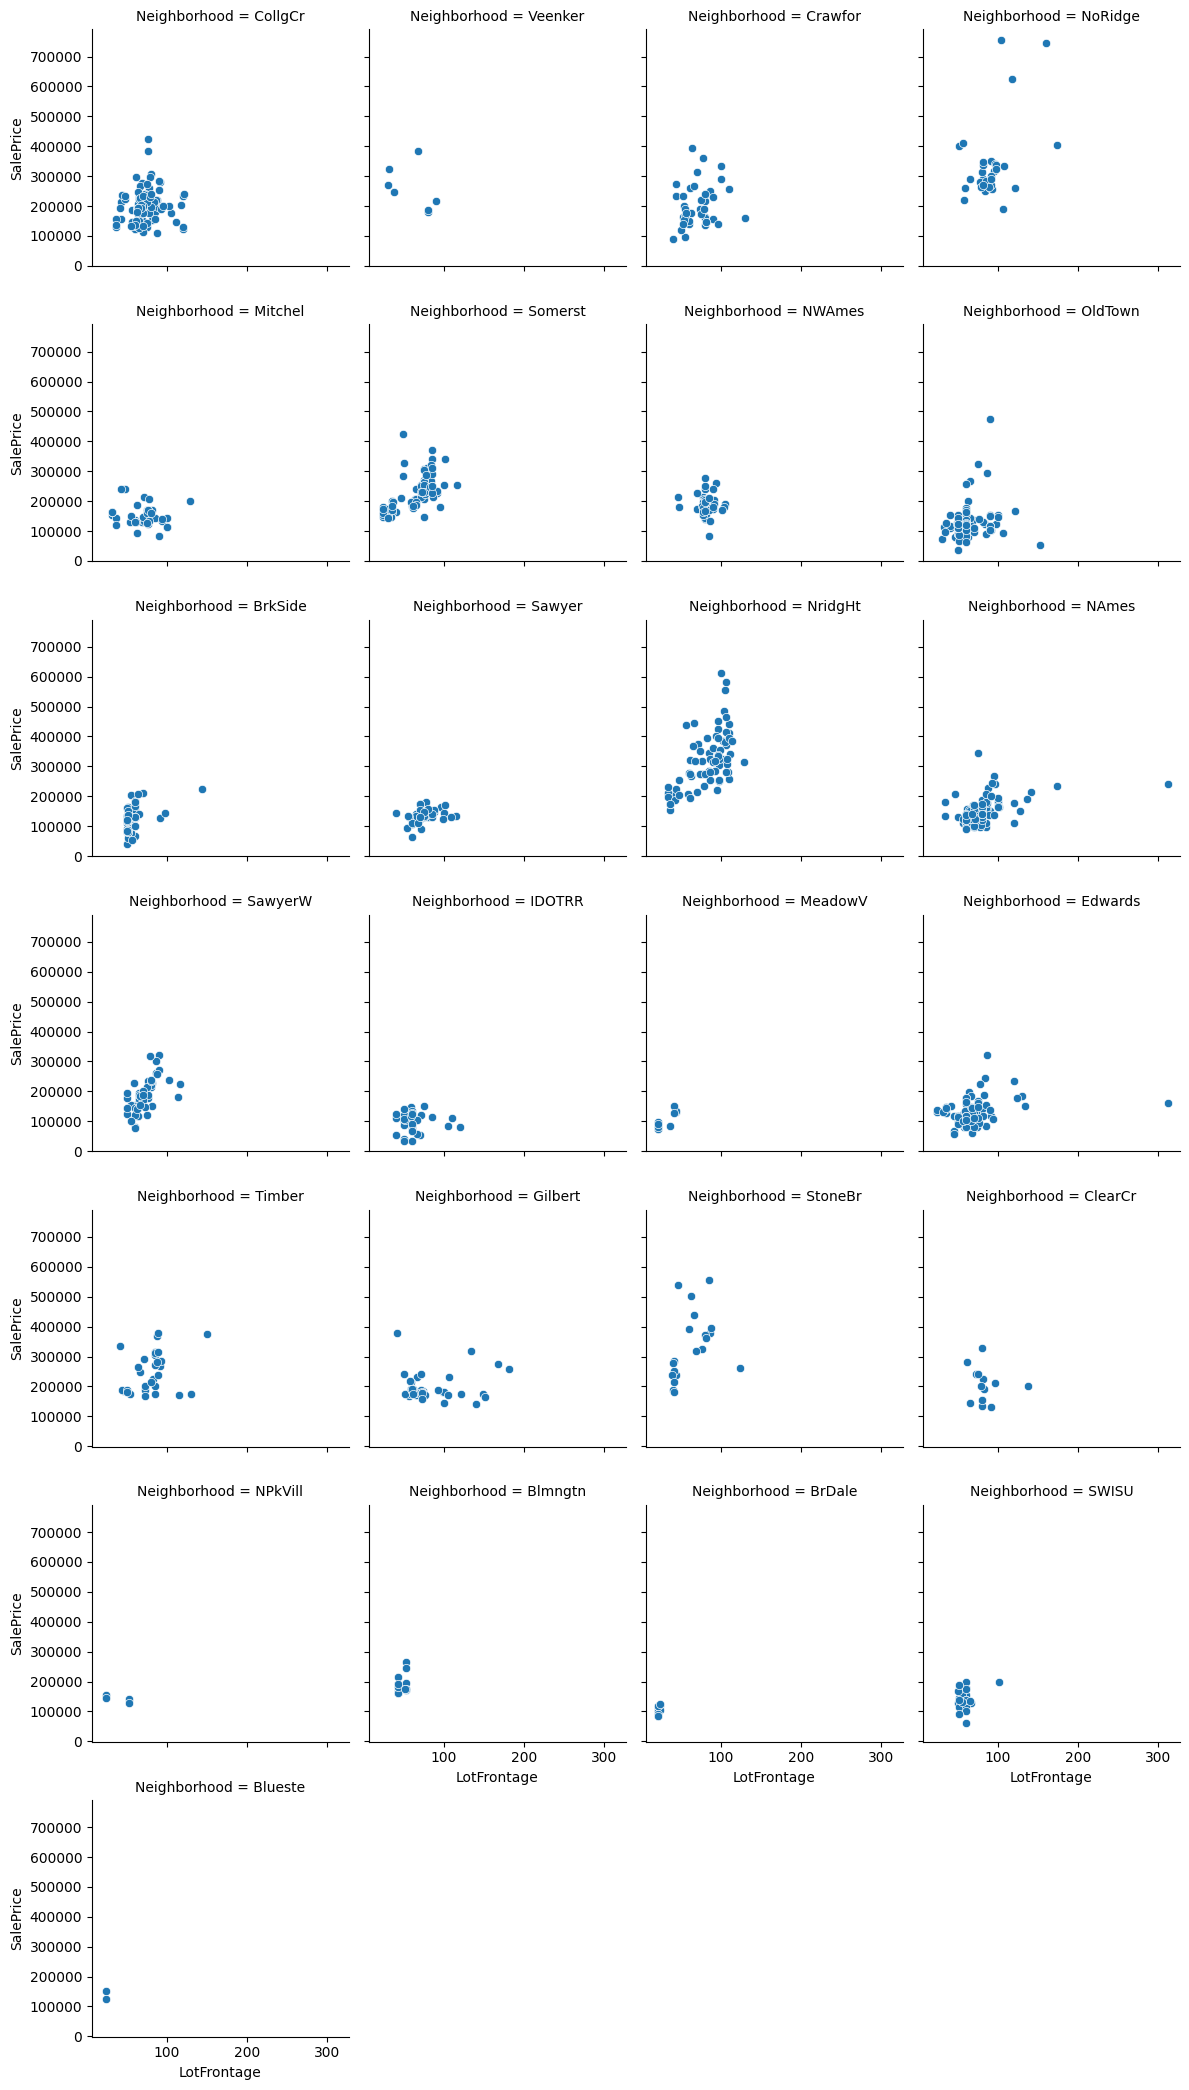

In [35]:
# sns.scatterplot(x=num_cols["LotFrontage"],y=num_cols["SalePrice"],hue=df["Neighborhood"])
# plt.show()
# g = sns.FacetGrid(
#     df,
#     col="Neighborhood",
#     col_wrap=4,
#     height=3
# )

# g.map_dataframe(
#     sns.scatterplot,
#     x="LotFrontage",
#     y="SalePrice"
# )
sns.relplot(data=df,x="LotFrontage",y="SalePrice",col="Neighborhood", col_wrap=4,height=3,kind="scatter")

plt.show()

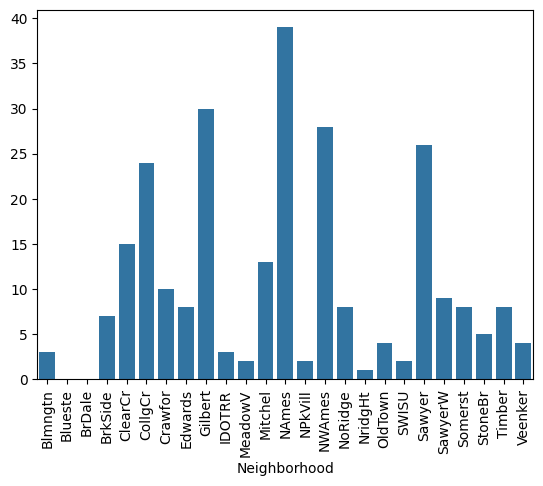

In [36]:
#LotFrontage-->having 259 null values
k=df["Neighborhood"].value_counts()-df.groupby("Neighborhood")["LotFrontage"].count()
# plt.bar(k.index,k.values)
sns.barplot(x=k.index,y=k.values)
plt.xticks(rotation=90)
plt.show()
#here we get

In [37]:
print(df["LotFrontage"].skew())
df.groupby("Neighborhood")["LotFrontage"].agg(["mean","median","count","size","skew","min","max"])

2.163569142324884


,mean,median,count,size,skew,min,max
Neighborhood,,,,,,,
Blmngtn,47.142857,43.0,14,17,0.356222,43.0,53.0
Blueste,24.000000,24.0,2,2,NaN,24.0,24.0
BrDale,21.562500,21.0,16,16,1.771925,21.0,24.0
BrkSide,57.509804,52.0,51,58,4.154470,50.0,144.0
ClearCr,83.461538,80.0,13,28,2.155355,62.0,138.0
CollgCr,71.682540,70.0,126,150,0.826432,36.0,122.0
Crawfor,71.804878,74.0,41,51,0.697890,40.0,130.0
Edwards,68.217391,65.5,92,100,4.942113,24.0,313.0
Gilbert,79.877551,65.0,49,79,1.660707,42.0,182.0


"LotFrontage shows substantial variation across Neighborhoods, and several Neighborhoods exhibit positive skewness. Therefore, Neighborhood-wise median imputation is chosen because the median is robust to extreme values and preserves the local distribution of LotFrontage better than a single global value."

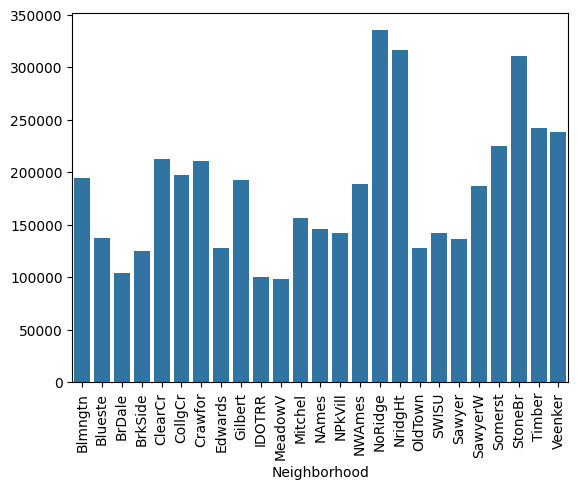

In [38]:
sns.barplot(x=df.groupby('Neighborhood')["SalePrice"].mean().index,y=df.groupby('Neighborhood')["SalePrice"].mean().values)
plt.xticks(rotation=90)
plt.show()
#

In [39]:
#overallquality
num_cols["OverallQual"].value_counts().sort_index()

,count
OverallQual,
1,2
2,3
3,20
4,116
5,397
6,374
7,319
8,168
9,43


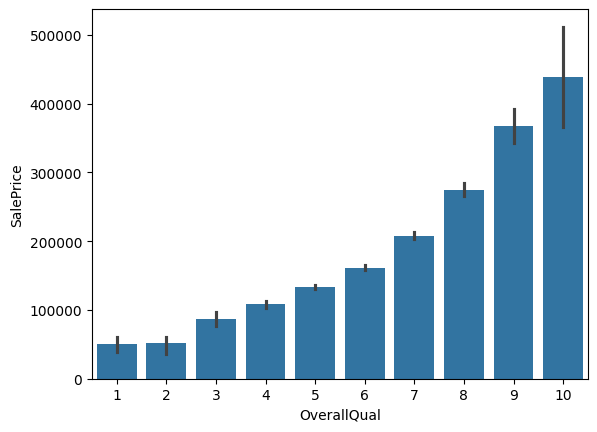

In [40]:
sns.barplot(x=num_cols["OverallQual"],y=num_cols["SalePrice"])
plt.show()

##we can see that overall quality is directly poroptional to sale-prices

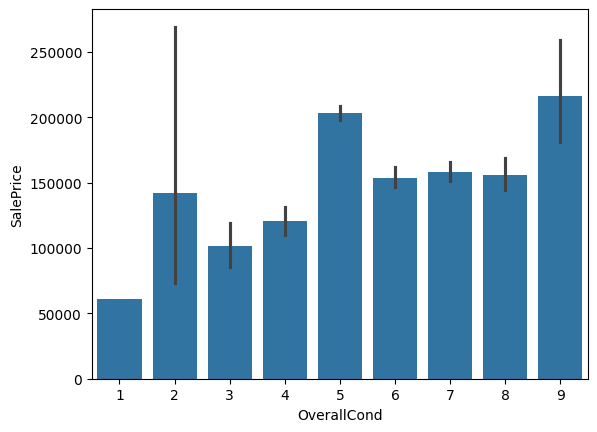

In [41]:
sns.barplot(x=num_cols["OverallCond"],y=num_cols["SalePrice"])
plt.show()

<Axes: xlabel='GarageCars', ylabel='SalePrice'>

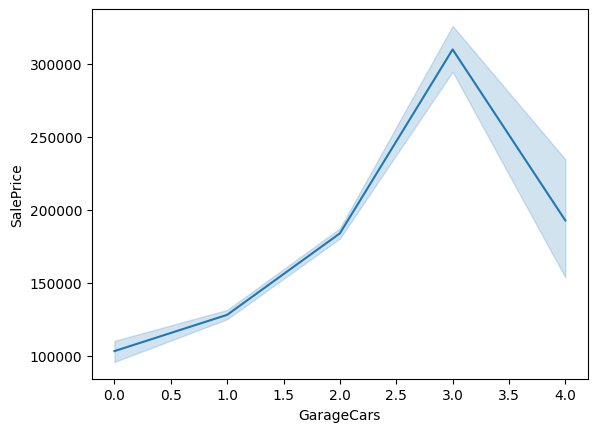

In [42]:
#  num_cols["GarageCars"].corr(num_cols["GarageArea"])
sns.lineplot(x=num_cols["GarageCars"],y=num_cols["SalePrice"])



<Axes: xlabel='GarageArea', ylabel='SalePrice'>

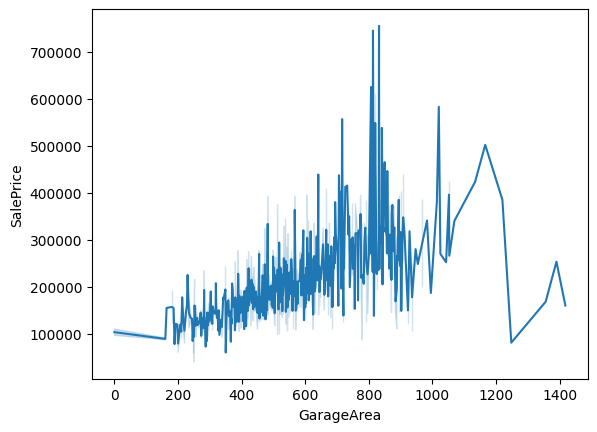

In [43]:
sns.lineplot(x=num_cols["GarageArea"],y=num_cols["SalePrice"])

As we can see that GarageCars giving us more strong relation with saleprice then GarageArea

##UNIVARIATE EDA ON CATEGORICAL COLUMNS

In [44]:
cat_cols.sample(5)

,MSZoning,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinType2,Heating,HeatingQC,CentralAir,Electrical,KitchenQual,Functional,FireplaceQu,GarageType,GarageFinish,GarageQual,GarageCond,PavedDrive,SaleType,SaleCondition
359,RL,Pave,IR1,Lvl,AllPub,CulDSac,Gtl,NoRidge,Norm,Norm,1Fam,2Story,Gable,CompShg,VinylSd,VinylSd,Gd,TA,PConc,Gd,TA,Av,GLQ,Unf,GasA,Ex,Y,SBrkr,Gd,Typ,TA,Attchd,RFn,TA,TA,Y,WD,Normal
535,RL,Pave,Reg,Lvl,AllPub,Inside,Gtl,Edwards,Norm,Norm,2fmCon,2Story,Gable,CompShg,MetalSd,MetalSd,TA,TA,CBlock,Gd,TA,Gd,GLQ,Unf,GasA,TA,Y,SBrkr,TA,Typ,NaN,NaN,NaN,NaN,NaN,N,WD,Normal
1186,RL,Pave,IR1,Bnk,AllPub,Corner,Mod,OldTown,Artery,Artery,2fmCon,2Story,Gable,CompShg,HdBoard,HdBoard,TA,TA,CBlock,Fa,TA,Mn,BLQ,Unf,GasA,TA,Y,SBrkr,TA,Typ,NaN,CarPort,Unf,Fa,Fa,Y,WD,Abnorml
589,RM,Pave,Reg,Lvl,AllPub,Inside,Gtl,BrkSide,RRAn,Feedr,1Fam,1Story,Gable,CompShg,VinylSd,VinylSd,TA,TA,BrkTil,TA,TA,No,Unf,Unf,GasA,TA,Y,FuseA,TA,Typ,NaN,Detchd,Unf,TA,TA,P,WD,Normal
75,RM,Pave,Reg,Lvl,AllPub,Inside,Gtl,MeadowV,Norm,Norm,Twnhs,SLvl,Gable,CompShg,CemntBd,CmentBd,TA,TA,CBlock,Gd,TA,Gd,GLQ,Unf,GasA,TA,Y,SBrkr,TA,Typ,NaN,BuiltIn,Unf,TA,TA,Y,WD,Normal


In [45]:
for col in cat_cols.columns:
  print(col)
  print(cat_cols[col].value_counts())
nom_col = [
    "MSZoning",
    "Street",
    "Utilities",
    "LotConfig",
    "Neighborhood",
    "RoofStyle",
    "RoofMatl",
    "Exterior1st",
    "Exterior2nd",
    "Foundation",
    "Heating",
    "CentralAir",
    "Electrical",
    "GarageType",
    "SaleType",
    "SaleCondition"
]
ord_col = [
    "LotShape",
    "LandSlope",
    "ExterQual",
    "ExterCond",
    "BsmtQual",
    "BsmtCond",
    "BsmtExposure",
    "BsmtFinType1",
    "BsmtFinType2",
    "HeatingQC",
    "KitchenQual",
    "Functional",
    "FireplaceQu",
    "GarageFinish",
    "GarageQual",
    "GarageCond",
    "PavedDrive"
]

MSZoning
MSZoning
RL         1151
RM          218
FV           65
RH           16
C (all)      10
Name: count, dtype: int64
Street
Street
Pave    1454
Grvl       6
Name: count, dtype: int64
LotShape
LotShape
Reg    925
IR1    484
IR2     41
IR3     10
Name: count, dtype: int64
LandContour
LandContour
Lvl    1311
Bnk      63
HLS      50
Low      36
Name: count, dtype: int64
Utilities
Utilities
AllPub    1459
NoSeWa       1
Name: count, dtype: int64
LotConfig
LotConfig
Inside     1052
Corner      263
CulDSac      94
FR2          47
FR3           4
Name: count, dtype: int64
LandSlope
LandSlope
Gtl    1382
Mod      65
Sev      13
Name: count, dtype: int64
Neighborhood
Neighborhood
NAmes      225
CollgCr    150
OldTown    113
Edwards    100
Somerst     86
Gilbert     79
NridgHt     77
Sawyer      74
NWAmes      73
SawyerW     59
BrkSide     58
Crawfor     51
Mitchel     49
NoRidge     41
Timber      38
IDOTRR      37
ClearCr     28
SWISU       25
StoneBr     25
Blmngtn     17
MeadowV     17

MSZoning


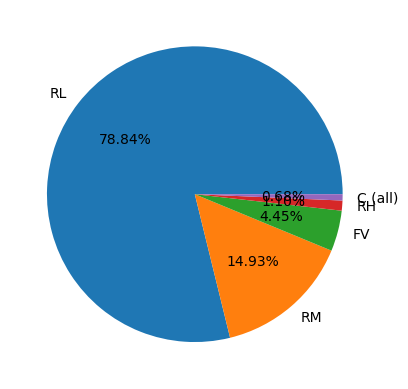

Street


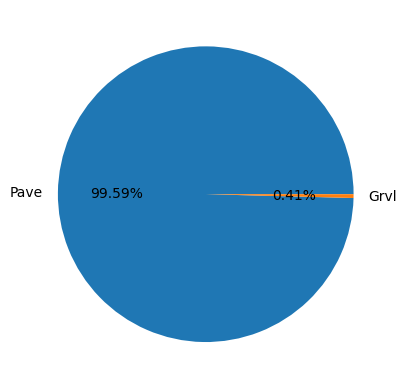

Utilities


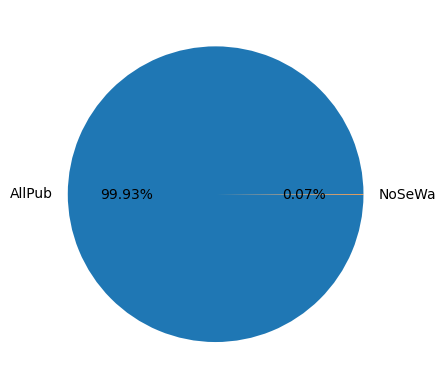

LotConfig


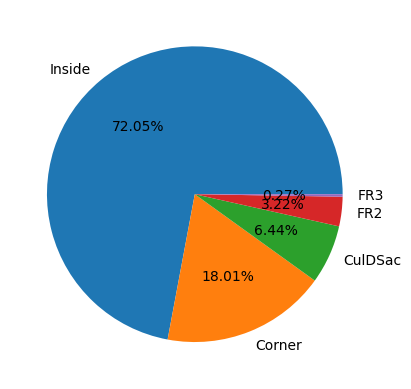

Neighborhood


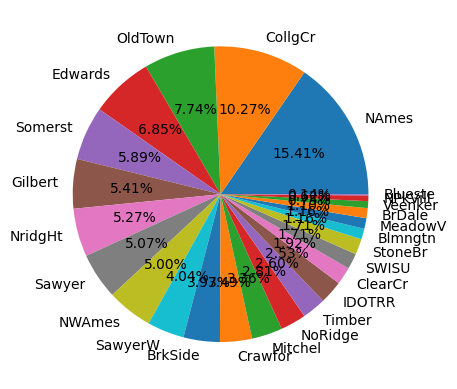

RoofStyle


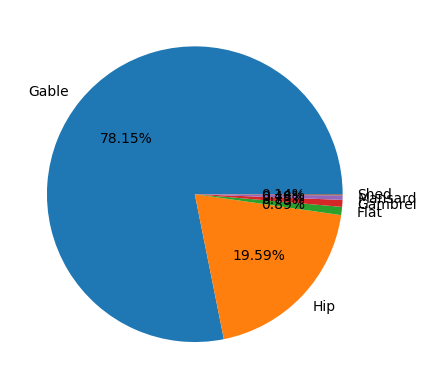

RoofMatl


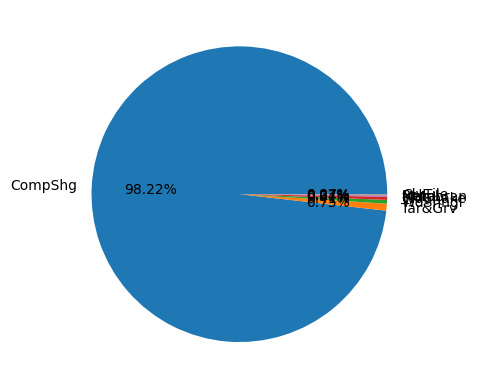

Exterior1st


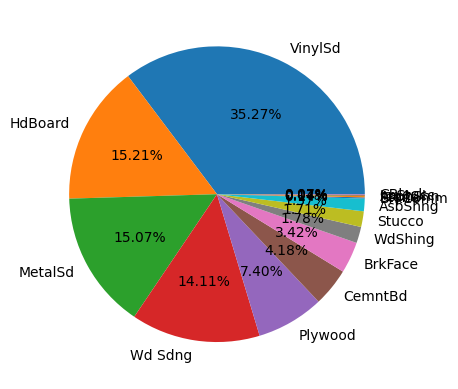

Exterior2nd


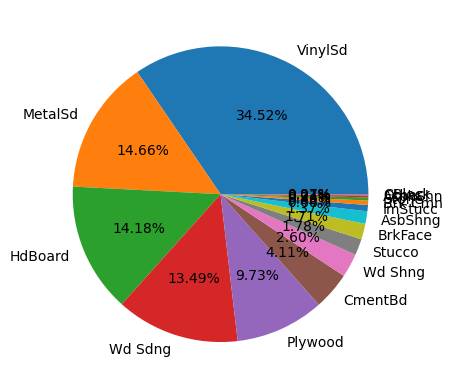

Foundation


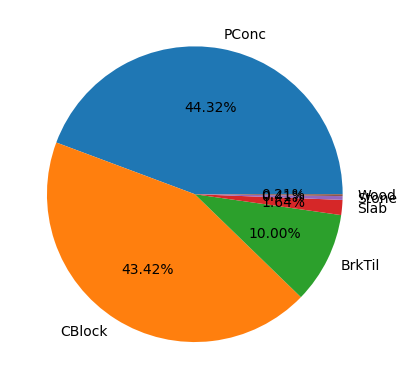

Heating


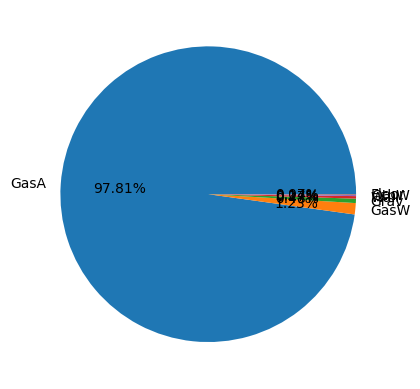

CentralAir


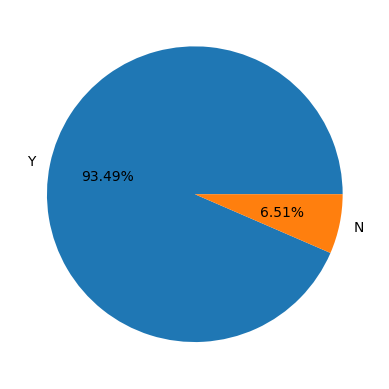

Electrical


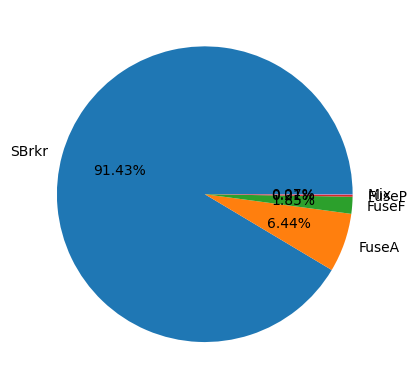

GarageType


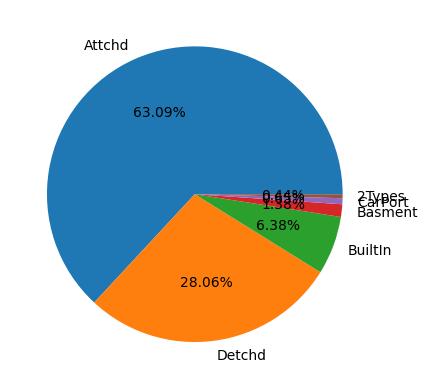

SaleType


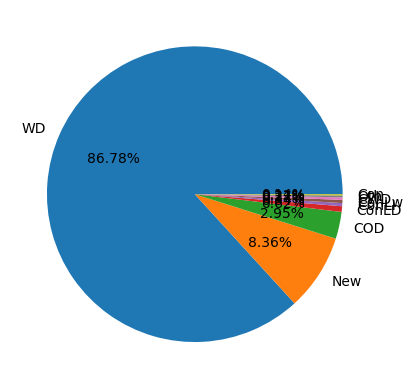

SaleCondition


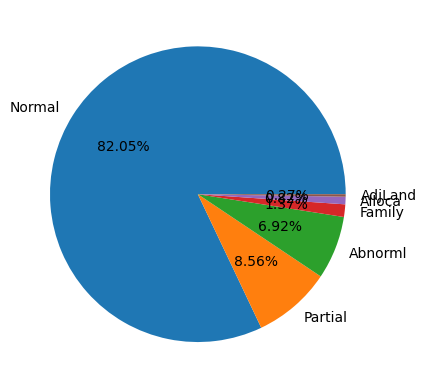

In [46]:
for col in nom_col:
  print(col)
  plt.pie(cat_cols[col].value_counts(),labels=cat_cols[col].value_counts().index,autopct="%1.2f%%")
  plt.show()

MSZoning


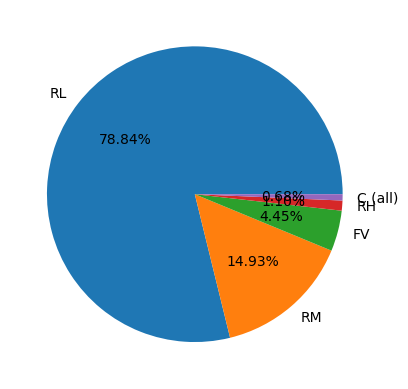

Street


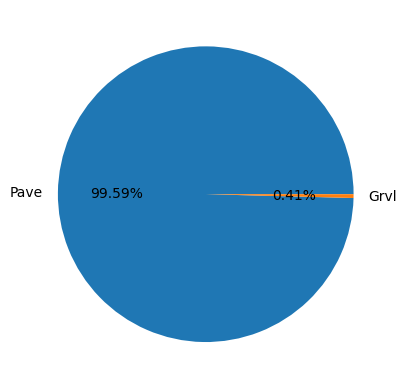

LotShape


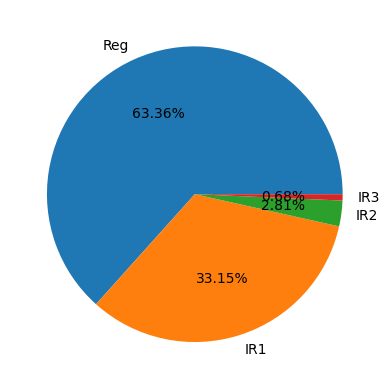

LandContour


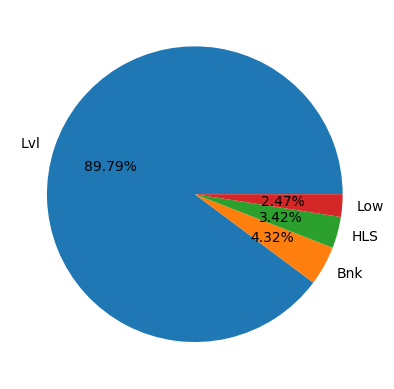

Utilities


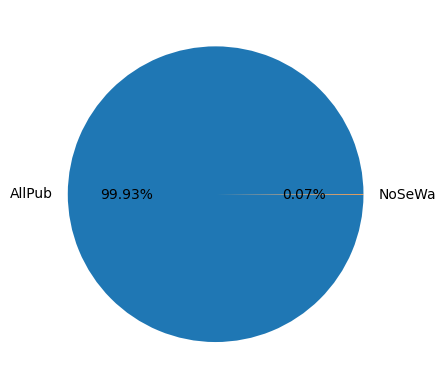

LotConfig


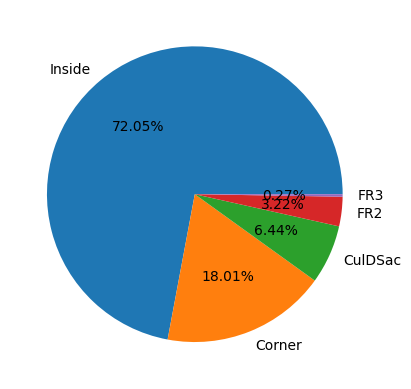

LandSlope


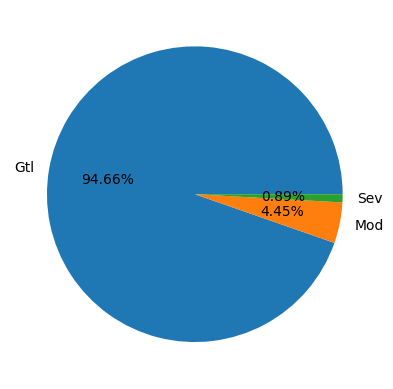

Neighborhood


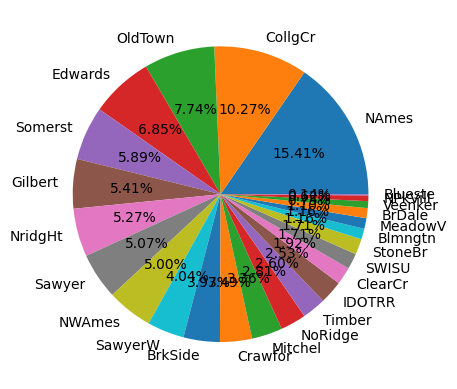

Condition1


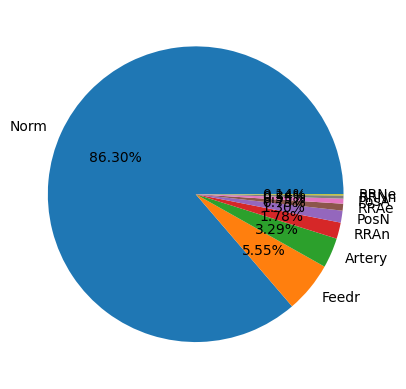

Condition2


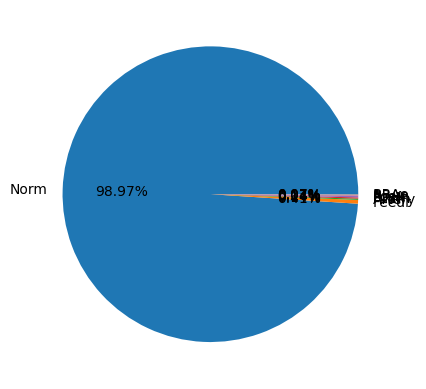

BldgType


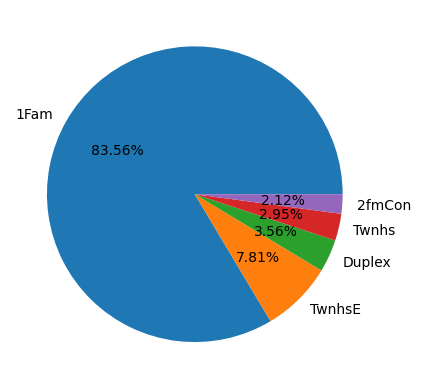

HouseStyle


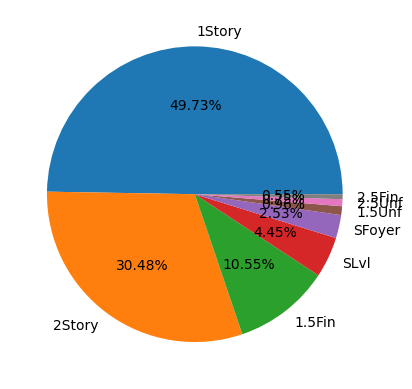

RoofStyle


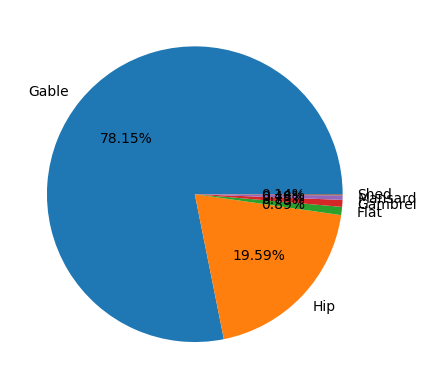

RoofMatl


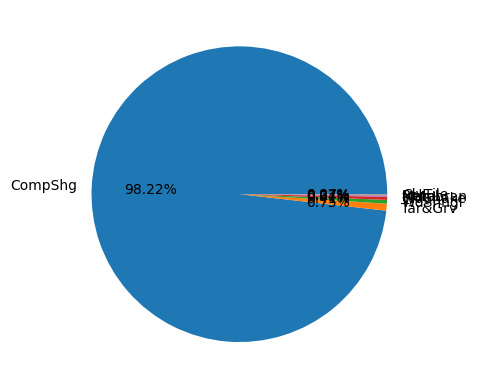

Exterior1st


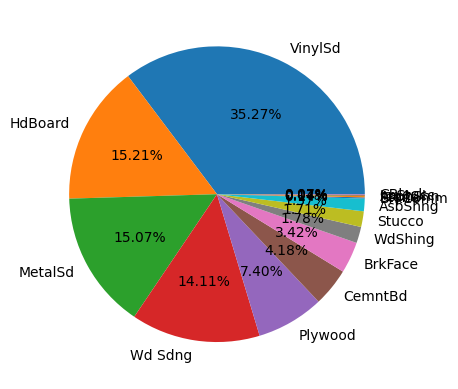

Exterior2nd


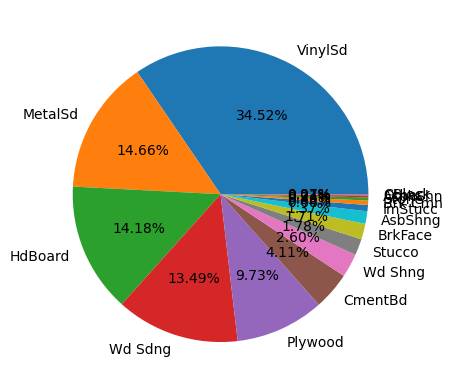

ExterQual


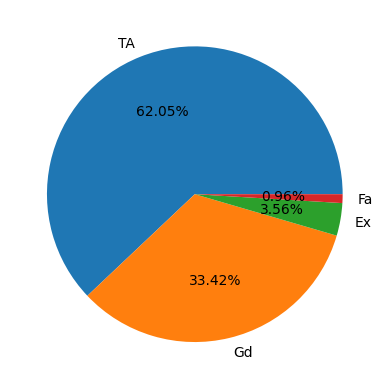

ExterCond


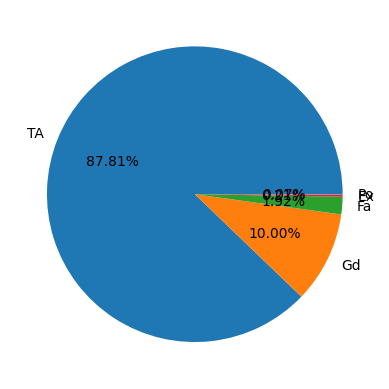

Foundation


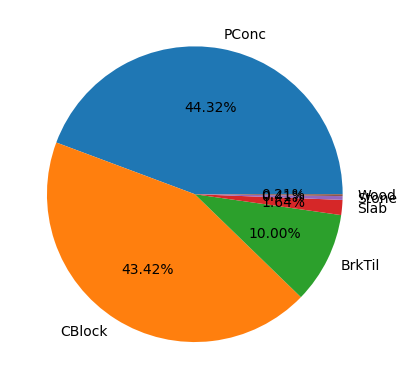

BsmtQual


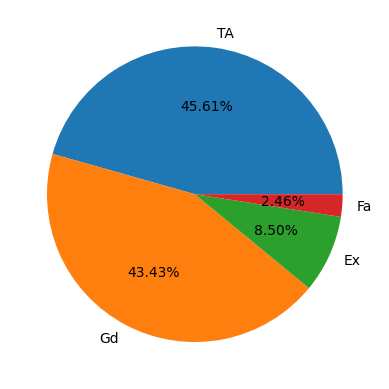

BsmtCond


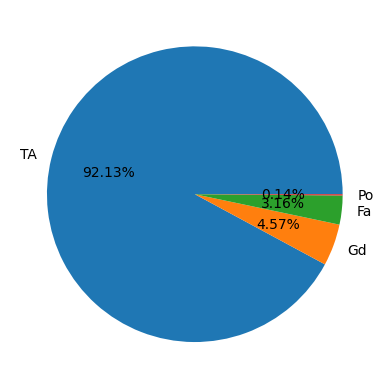

BsmtExposure


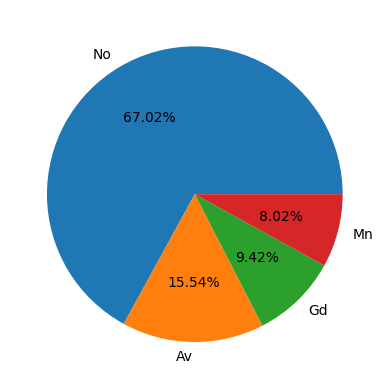

BsmtFinType1


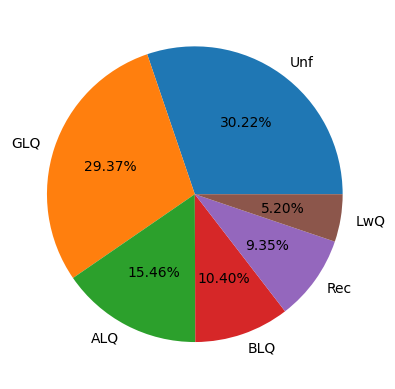

BsmtFinType2


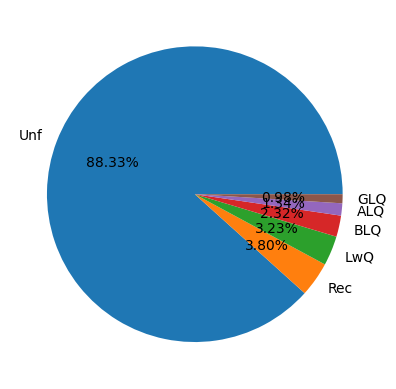

Heating


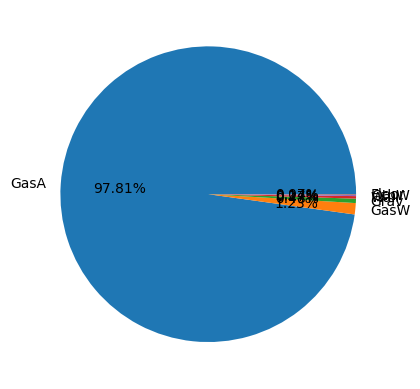

HeatingQC


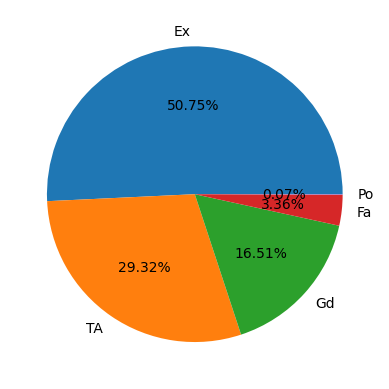

CentralAir


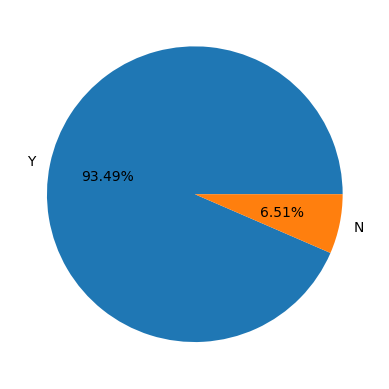

Electrical


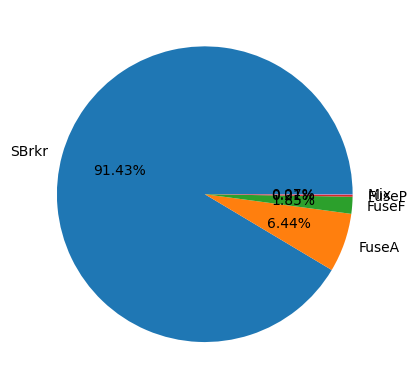

KitchenQual


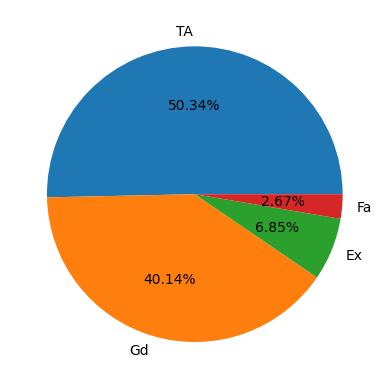

Functional


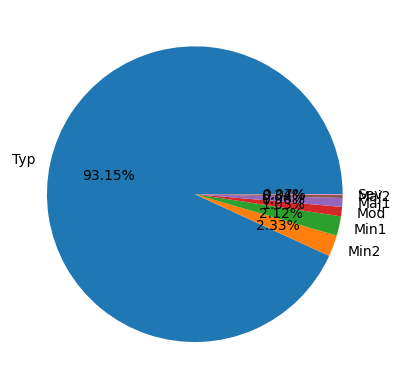

FireplaceQu


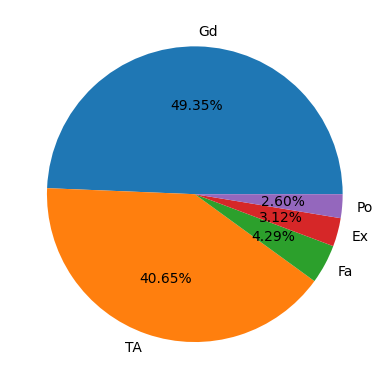

GarageType


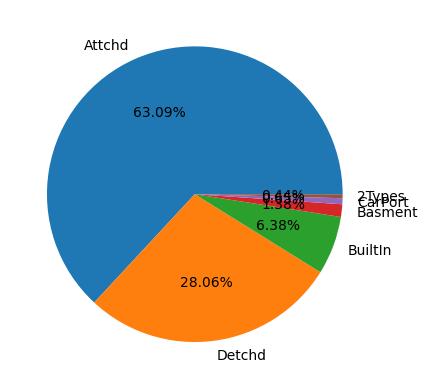

GarageFinish


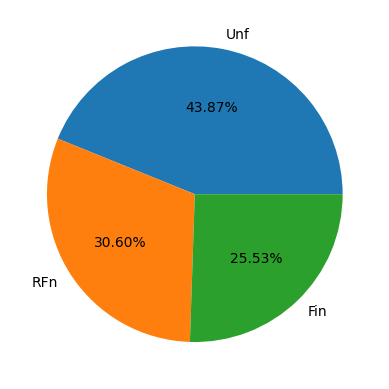

GarageQual


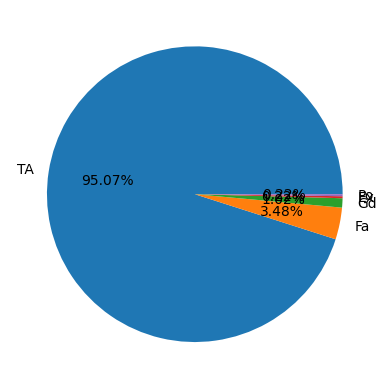

GarageCond


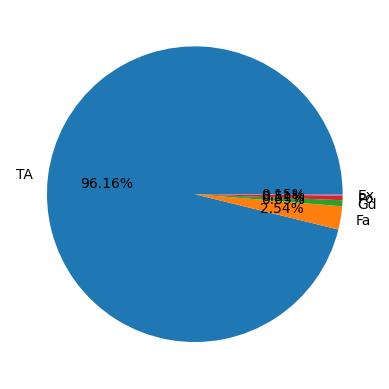

PavedDrive


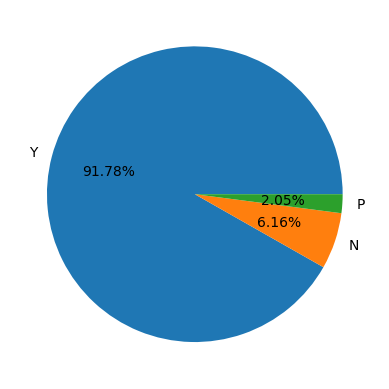

SaleType


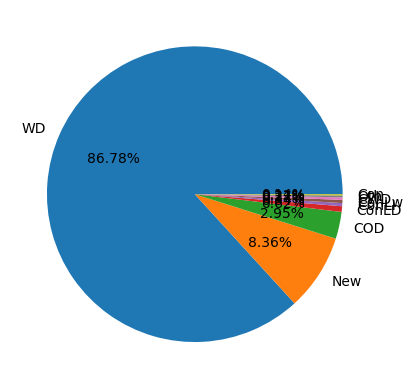

SaleCondition


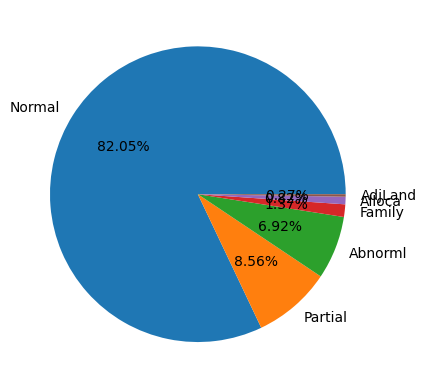

In [47]:
for col in cat_cols.columns:
  print(col)
  plt.pie(cat_cols[col].value_counts(),labels=cat_cols[col].value_counts().index,autopct="%1.2f%%")
  plt.show()

##Encoding

In [48]:
ord_col

['LotShape',
 'LandSlope',
 'ExterQual',
 'ExterCond',
 'BsmtQual',
 'BsmtCond',
 'BsmtExposure',
 'BsmtFinType1',
 'BsmtFinType2',
 'HeatingQC',
 'KitchenQual',
 'Functional',
 'FireplaceQu',
 'GarageFinish',
 'GarageQual',
 'GarageCond',
 'PavedDrive']

In [49]:
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
ordinal_categories = [
    ["IR3", "IR2", "IR1", "Reg"],                         # LotShape
    ["Sev", "Mod", "Gtl"],                                # LandSlope
    ["Po", "Fa", "TA", "Gd", "Ex"],                       # ExterQual
    ["Po", "Fa", "TA", "Gd", "Ex"],                       # ExterCond
    ["NA", "Po", "Fa", "TA", "Gd", "Ex"],                # BsmtQual
    ["NA", "Po", "Fa", "TA", "Gd", "Ex"],                # BsmtCond
    ["NA", "No", "Mn", "Av", "Gd"],                      # BsmtExposure
    ["NA", "Unf", "LwQ", "Rec", "BLQ", "ALQ", "GLQ"],   # BsmtFinType1
    ["NA", "Unf", "LwQ", "Rec", "BLQ", "ALQ", "GLQ"],   # BsmtFinType2
    ["Po", "Fa", "TA", "Gd", "Ex"],                       # HeatingQC
    ["Po", "Fa", "TA", "Gd", "Ex"],                       # KitchenQual
    ["Sal", "Sev", "Maj2", "Maj1", "Mod", "Min2", "Min1", "Typ"],  # Functional
    ["NA", "Po", "Fa", "TA", "Gd", "Ex"],                # FireplaceQu
    ["NA", "Unf", "RFn", "Fin"],                          # GarageFinish
    ["NA", "Po", "Fa", "TA", "Gd", "Ex"],                # GarageQual
    ["NA", "Po", "Fa", "TA", "Gd", "Ex"],                # GarageCond
    ["N", "P", "Y"]                                      # PavedDrive
]


In [50]:
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
ord=OrdinalEncoder(
    categories=ordinal_categories,handle_unknown="use_encoded_value",unknown_value=-1
)
ohe_transformer = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)
transformer=ColumnTransformer(
    transformers=[
        ("ord",ord,ord_col),
        ("ohe",ohe_transformer,nom_col)
    ],
    remainder="passthrough"
)


In [51]:
k=pd.concat([slected_col,df[ord_col],df[nom_col]],axis =1)
print(k.shape[1])


49


In [52]:
slected_col.columns

Index(['OverallQual', 'GrLivArea', 'GarageCars', 'TotalBsmtSF', '1stFlrSF',
       'FullBath', 'TotRmsAbvGrd', 'YearBuilt', 'OverallQualtransformed',
       'GrLivAreatransformed', 'GarageCarstransformed',
       'TotalBsmtSFtransformed', '1stFlrSFtransformed', 'FullBathtransformed',
       'TotRmsAbvGrdtransformed', 'YearBuilttransformed'],
      dtype='object')

In [53]:
from sklearn.model_selection import train_test_split

X = k
y = df["SalePrice"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [54]:
X_train_encoded=transformer.fit_transform(X_train)
X_test_encoded=transformer.transform(X_test)

In [55]:
X_train_encoded

array([[ 3.        ,  2.        ,  2.        , ..., -1.02517285,
        -0.94736174, -0.62270109],
       [ 2.        ,  2.        ,  3.        , ...,  0.79724606,
         0.38992075,  0.68907741],
       [ 3.        ,  2.        ,  2.        , ..., -1.02517285,
        -1.77907303, -1.72139987],
       ...,
       [ 3.        ,  2.        ,  2.        , ..., -1.02517285,
        -0.94736174, -0.68177458],
       [ 3.        ,  2.        ,  3.        , ..., -1.02517285,
         0.38992075, -1.57194325],
       [ 3.        ,  2.        ,  3.        , ...,  0.79724606,
         0.38992075,  1.35109769]])

#feature selection

The numerical Features we are going to selects are
OverallQual
GrLivArea
GarageCars
TotalBsmtSF
1stFlrSF
FullBath
TotRmsAbvGrd
YearBuilt

The categorical Features we are going to selects are

In [56]:
from sklearn.linear_model import LinearRegression
lr=LinearRegression()
lr.fit(X_train_encoded,y_train)

LinearRegression()

In [57]:
from sklearn.metrics import r2_score
y_pred=lr.predict(X_test_encoded)
r2_score(y_test,y_pred)

0.8792300651733878

In [58]:
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=1.0)

ridge.fit(X_train_encoded, y_train)

y_pred_ridge = ridge.predict(X_test_encoded)

print("Ridge R2:", r2_score(y_test, y_pred_ridge))

Ridge R2: 0.873021129715453


In [60]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train_encoded, y_train)

y_pred_rf = rf.predict(X_test_encoded)

print("Random Forest R2:", r2_score(y_test, y_pred_rf))

Random Forest R2: 0.8817171220960934


In [61]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [62]:
models = {
    "Linear Regression": LinearRegression(),

    "Ridge": Ridge(alpha=1.0),

    "Random Forest": RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    )
}

In [63]:
results = []

for name, model in models.items():

    model.fit(X_train_encoded, y_train)

    y_pred = model.predict(X_test_encoded)

    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = mean_squared_error(y_test, y_pred) ** 0.5

    results.append({
        "Model": name,
        "R2": r2,
        "MAE": mae,
        "RMSE": rmse
    })

In [64]:
import pandas as pd

results_df = pd.DataFrame(results)

results_df.sort_values(
    by="R2",
    ascending=False
)

,Model,R2,MAE,RMSE
3,Gradient Boosting,0.902722,17151.126572,27315.793884
2,Random Forest,0.881717,17772.366761,30120.894048
0,Linear Regression,0.879230,19210.991642,30435.912934
1,Ridge,0.873021,19156.268120,31208.482124
